# Análise Exploratória de Dados


In [141]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss

ROOT_PATH = os.path.dirname(os.getcwd())
DATA_FOLDER_PATH = os.path.join(ROOT_PATH, 'data', 'processed')

COVID_START = pd.Timestamp('2020-04-01')  # first pandemic month: April 2020
COVID_END = pd.Timestamp('2021-12-31')

sns.set_palette('colorblind')

### Funções Auxiliares — Modern Time Series Forecasting with Python (2E)

As verificações de tendência, sazonalidade, heterocedasticidade e transformações abaixo utilizam funções auxiliares
do repositório que acompanha o livro:

> Joseph, M. & Tackes, J. *Modern Time Series Forecasting with Python*, 2ª ed. (Packt, 2024) — [PacktPublishing/Modern-Time-Series-Forecasting-with-Python-2E](https://github.com/PacktPublishing/Modern-Time-Series-Forecasting-with-Python-2E), Licença MIT

| Função Auxiliar | Arquivo fonte | Finalidade |
|---|---|---|
| `check_trend` | `src/transforms/stationary_utils.py` | Testes de tendência de Kendall (τ) e Mann-Kendall |
| `check_deterministic_trend` | `src/transforms/stationary_utils.py` | Verificação de tendência determinística via ADF (`c` vs `ct`) |
| `check_seasonality` | `src/transforms/stationary_utils.py` | Teste de significância de FAC + fórmula de Bartlett (adaptado de `darts`) |
| `check_heteroscedastisticity` | `src/transforms/stationary_utils.py` | Teste de White em ajuste de tendência linear |
| `DetrendingTransformer` | `src/transforms/target_transformations.py` | Remoção de tendência linear (detrending) |
| `DeseasonalizingTransformer` | `src/transforms/target_transformations.py` | Remoção de sazonalidade por médias do período (deseasonalizing) |
| `BoxCoxTransformer` | `src/transforms/target_transformations.py` | Box-Cox com método de Guerrero para λ (adaptado de `sktime`) |
| `AutoStationaryTransformer` | `src/transforms/target_transformations.py` | Pipeline automático: detrend → deseasonalize → Box-Cox |

O repositório é esperado como uma pasta irmã deste projeto (configurável pela variável de ambiente
`MTSF_REPO_PATH`). Seu pacote `src` necessita de `plotly` e `pymannkendall`, ambos listados no `pyproject.toml`.


In [142]:
import sys

# Helpers credited to: Joseph, M. & Tackes, J. "Modern Time Series Forecasting with
# Python", 2nd ed. (Packt, 2024) — MIT License
# github.com/PacktPublishing/Modern-Time-Series-Forecasting-with-Python-2E
MTSF_REPO_PATH = os.getenv(
    'MTSF_REPO_PATH',
    os.path.join(
        os.path.dirname(ROOT_PATH), 'Modern-Time-Series-Forecasting-with-Python-2E'
    ),
)
if MTSF_REPO_PATH not in sys.path:
    sys.path.insert(0, MTSF_REPO_PATH)

from src.transforms.stationary_utils import (  # noqa: E402
    check_deterministic_trend,
    check_heteroscedastisticity,
    check_seasonality,
    check_trend,
)
from src.transforms.target_transformations import (  # noqa: E402
    AutoStationaryTransformer,
    BoxCoxTransformer,
    DeseasonalizingTransformer,
    DetrendingTransformer,
)

SEASONAL_PERIOD = 12
FREQ = 'ME'

## Importação de Dados

A EDA utiliza **treino + validação** (`train_ptbr.parquet` e `val_ptbr.parquet`, notebook 2). O conjunto de teste
(os últimos 12 meses) nunca é lido aqui: ele é reservado exclusivamente para a avaliação final.


In [143]:
df = pd.concat(
    [
        pd.read_parquet(os.path.join(DATA_FOLDER_PATH, file_name))
        for file_name in ['train_ptbr.parquet', 'val_ptbr.parquet']
    ],
    ignore_index=True,
)

df = df.set_index('date')
df['is_covid_19'] = (df.index >= COVID_START) & (df.index <= COVID_END)

df.head()


,access_route,state,origin_country,month,year,arrival_count,month_num,year_month,state_region,country_cultural_subdivision,is_covid_19
date,,,,,,,,,,,
1989-01-31,Aérea,Amazonas,África do Sul,Janeiro,1989,9.0,01,1989-01-31,Região Norte,Sub-Saharan Africa,False
1989-01-31,Aérea,Amazonas,Angola,Janeiro,1989,0.0,01,1989-01-31,Região Norte,Sub-Saharan Africa,False
1989-01-31,Aérea,Amazonas,Nigéria,Janeiro,1989,0.0,01,1989-01-31,Região Norte,Sub-Saharan Africa,False
1989-01-31,Aérea,Amazonas,Outros países,Janeiro,1989,0.0,01,1989-01-31,Região Norte,Outros,False
1989-01-31,Aérea,Amazonas,Costa Rica,Janeiro,1989,6.0,01,1989-01-31,Região Norte,LATAM,False


## Análise de Variáveis Categóricas


### Via de Acesso


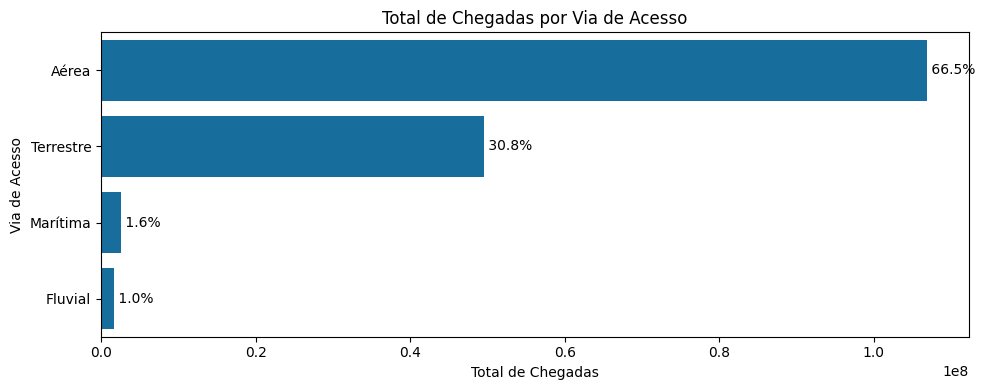

In [144]:
top_access_route = pd.DataFrame(
    df.groupby('access_route')['arrival_count'].sum().nlargest(20)
)
top_access_route['percentage'] = (
    top_access_route['arrival_count'] / top_access_route['arrival_count'].sum()
) * 100

plt.figure(figsize=(10, 4))

sns.barplot(x=top_access_route['arrival_count'], y=top_access_route.index)
plt.title('Total de Chegadas por Via de Acesso')
plt.xlabel('Total de Chegadas')
plt.ylabel('Via de Acesso')

ax = plt.gca()
for i, (count, pct) in enumerate(
    zip(top_access_route['arrival_count'], top_access_route['percentage'])
):
    ax.text(count, i, f' {pct:.1f}%', va='center', ha='left')

plt.tight_layout()

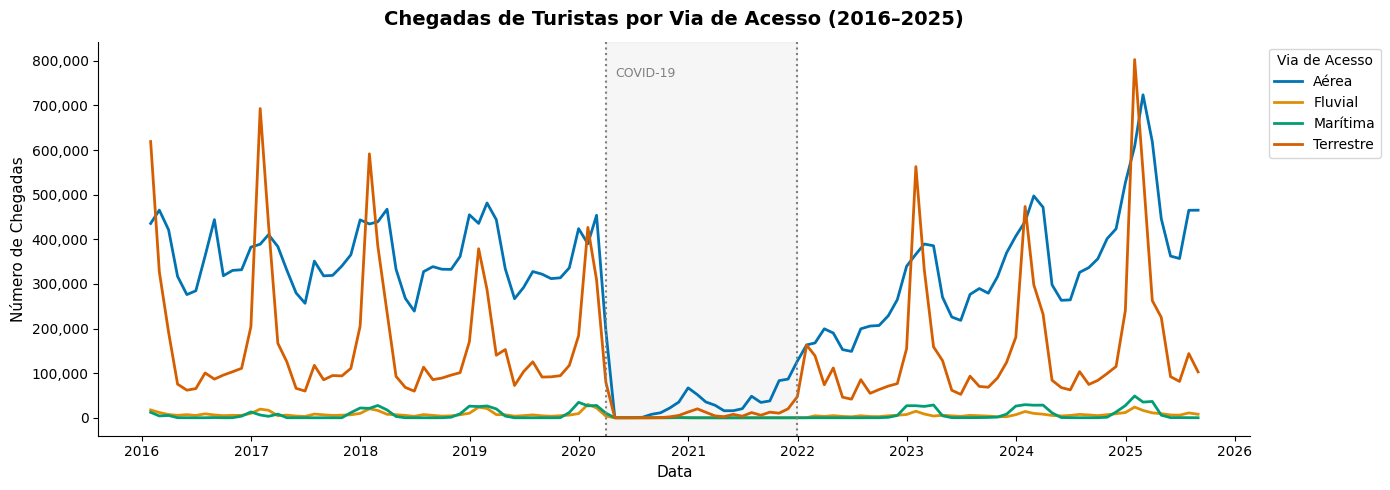

In [145]:
route_time = (
    df[df.index.year >= 2016]
    .groupby(['year_month', 'access_route'], as_index=False)['arrival_count']
    .sum()
)

fig, ax = plt.subplots(figsize=(14, 5))

sns.lineplot(
    data=route_time,
    x='year_month',
    y='arrival_count',
    hue='access_route',
    linewidth=2,
    ax=ax,
)

ax.axvline(COVID_START, color='gray', linestyle=':', linewidth=1.5, label='_nolegend_')
ax.axvline(COVID_END, color='gray', linestyle=':', linewidth=1.5, label='_nolegend_')
ax.axvspan(COVID_START, COVID_END, alpha=0.07, color='gray')

y_max = route_time['arrival_count'].max()
ax.text(
    COVID_START + pd.Timedelta(days=30),
    y_max * 0.95,
    'COVID-19',
    fontsize=9,
    color='gray',
)

ax.set_title(
    f'Chegadas de Turistas por Via de Acesso (2016–{df.index.year.max()})',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Data', fontsize=11)
ax.set_ylabel('Número de Chegadas', fontsize=11)
ax.legend(
    title='Via de Acesso', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=True
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()


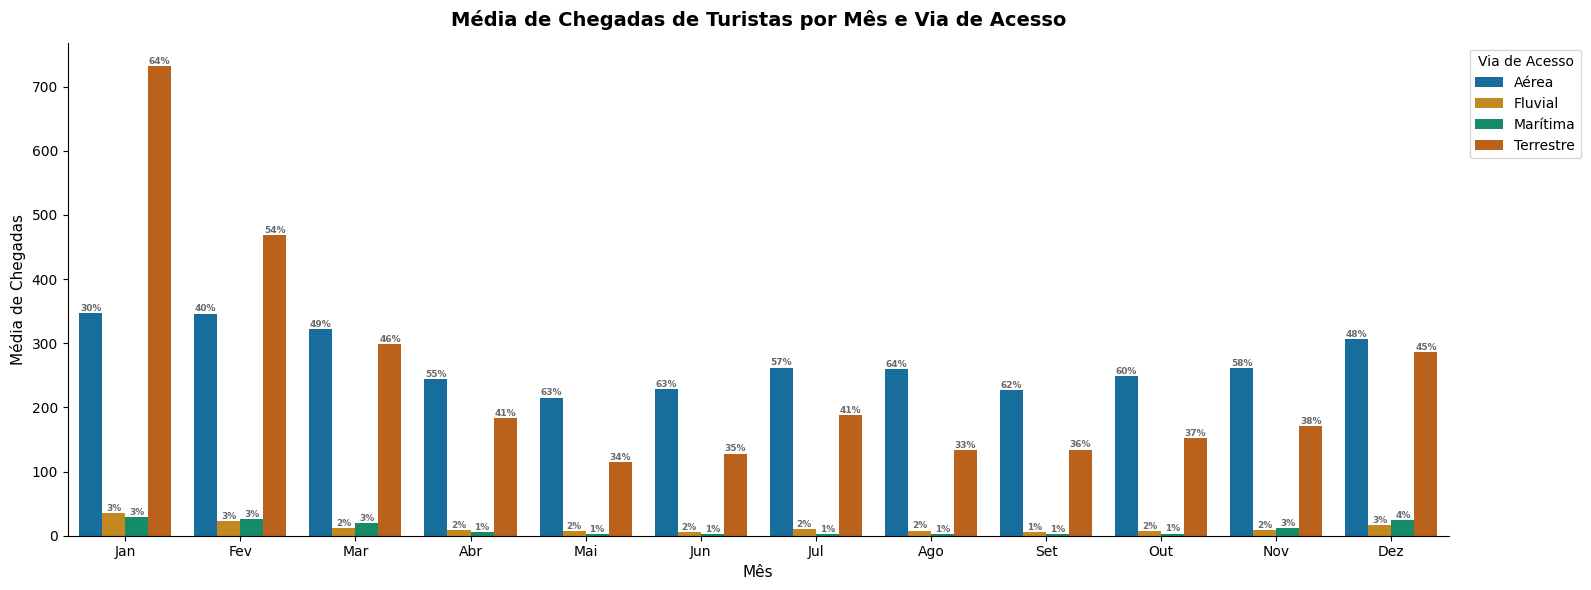

In [146]:
month_route = (
    df.groupby(['month_num', 'access_route'])['arrival_count'].mean().reset_index()
)

month_totals = month_route.groupby('month_num')['arrival_count'].sum()
month_route['pct'] = month_route.apply(
    lambda r: r['arrival_count'] / month_totals[r['month_num']] * 100, axis=1
)

month_labels = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
month_route['month_label'] = (
    month_route['month_num'].astype(int).apply(lambda m: month_labels[m - 1])
)

fig, ax = plt.subplots(figsize=(16, 6))

sns.barplot(
    data=month_route,
    x='month_label',
    y='arrival_count',
    hue='access_route',
    order=month_labels,
    ax=ax,
)

for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        x = bar.get_x() + bar.get_width() / 2
        ax.text(
            x,
            height + 0.5,
            f'{height / month_route["arrival_count"].max() * 100:.0f}%',
            ha='center',
            va='bottom',
            fontsize=6.5,
            color='dimgray',
        )

# re-annotate with actual pct values per bar group
ax.cla()
bar_plot = sns.barplot(
    data=month_route,
    x='month_label',
    y='arrival_count',
    hue='access_route',
    order=month_labels,
    ax=ax,
)

routes = month_route['access_route'].unique()
for month_idx, month in enumerate(month_labels):
    month_data = month_route[month_route['month_label'] == month].set_index(
        'access_route'
    )
    n_routes = len(routes)
    total_width = 0.8
    bar_width = total_width / n_routes
    for route_idx, route in enumerate(routes):
        if route not in month_data.index:
            continue
        row = month_data.loc[route]
        x = month_idx - total_width / 2 + bar_width * route_idx + bar_width / 2
        ax.text(
            x,
            row['arrival_count'] + 0.3,
            f'{row["pct"]:.0f}%',
            ha='center',
            va='bottom',
            fontsize=6.5,
            color='dimgray',
            fontweight='bold',
        )

ax.set_title(
    'Média de Chegadas de Turistas por Mês e Via de Acesso',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Mês', fontsize=11)
ax.set_ylabel('Média de Chegadas', fontsize=11)
ax.legend(
    title='Via de Acesso', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=True
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()


### Estado e Região de Chegada


#### Estado de Chegada (UF)


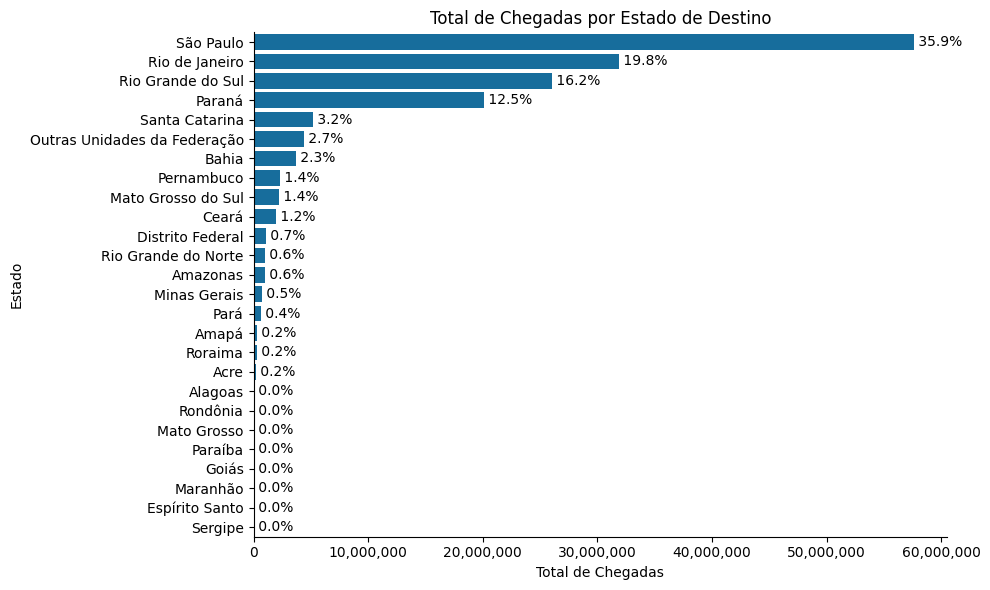

In [147]:
top_states = pd.DataFrame(df.groupby('state')['arrival_count'].sum().nlargest(30))
top_states['percentage'] = (
    top_states['arrival_count'] / top_states['arrival_count'].sum()
) * 100

plt.figure(figsize=(10, 6))

sns.barplot(x=top_states['arrival_count'], y=top_states.index)
plt.title('Total de Chegadas por Estado de Destino')
plt.xlabel('Total de Chegadas')
plt.ylabel('Estado')

ax = plt.gca()
for i, (count, pct) in enumerate(
    zip(top_states['arrival_count'], top_states['percentage'])
):
    ax.text(count, i, f' {pct:.1f}%', va='center', ha='left')

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()

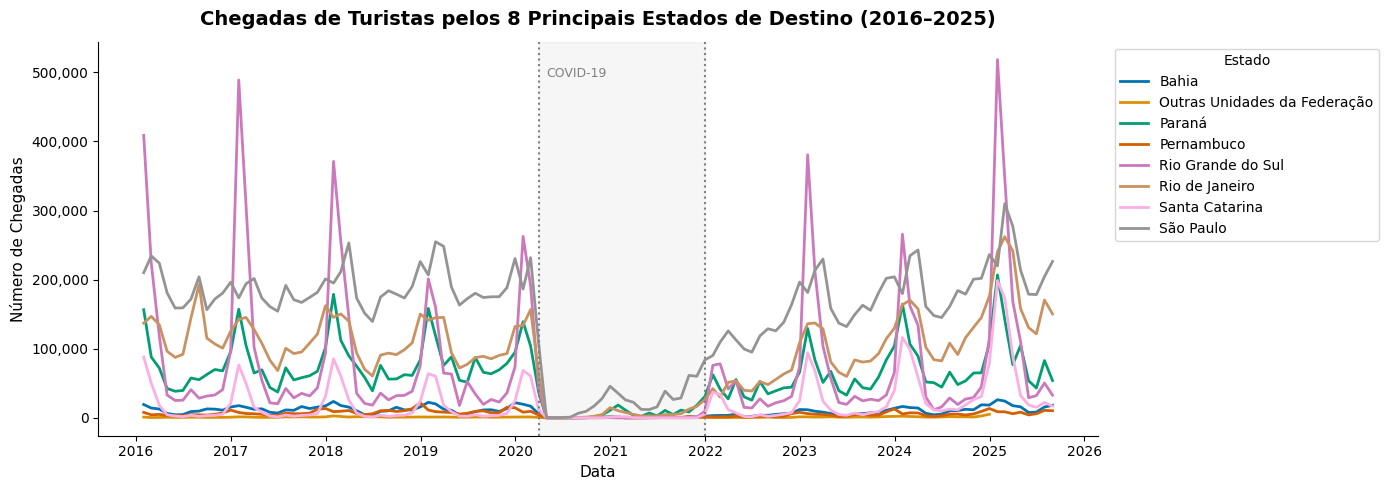

In [148]:
TOP_N = 8
top_state_names = (
    df.groupby('state')['arrival_count'].sum().nlargest(TOP_N).index.tolist()
)

state_time = (
    df[df['state'].isin(top_state_names) & (df.index.year >= 2016)]
    .groupby(['year_month', 'state'], as_index=False)['arrival_count']
    .sum()
)

fig, ax = plt.subplots(figsize=(14, 5))

sns.lineplot(
    data=state_time,
    x='year_month',
    y='arrival_count',
    hue='state',
    linewidth=2,
    ax=ax,
)

ax.axvline(COVID_START, color='gray', linestyle=':', linewidth=1.5, label='_nolegend_')
ax.axvline(COVID_END, color='gray', linestyle=':', linewidth=1.5, label='_nolegend_')
ax.axvspan(COVID_START, COVID_END, alpha=0.07, color='gray')

y_max = state_time['arrival_count'].max()
ax.text(
    COVID_START + pd.Timedelta(days=30),
    y_max * 0.95,
    'COVID-19',
    fontsize=9,
    color='gray',
)

ax.set_title(
    f'Chegadas de Turistas pelos {TOP_N} Principais Estados de Destino (2016–{df.index.year.max()})',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Data', fontsize=11)
ax.set_ylabel('Número de Chegadas', fontsize=11)
ax.legend(title='Estado', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=True)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()


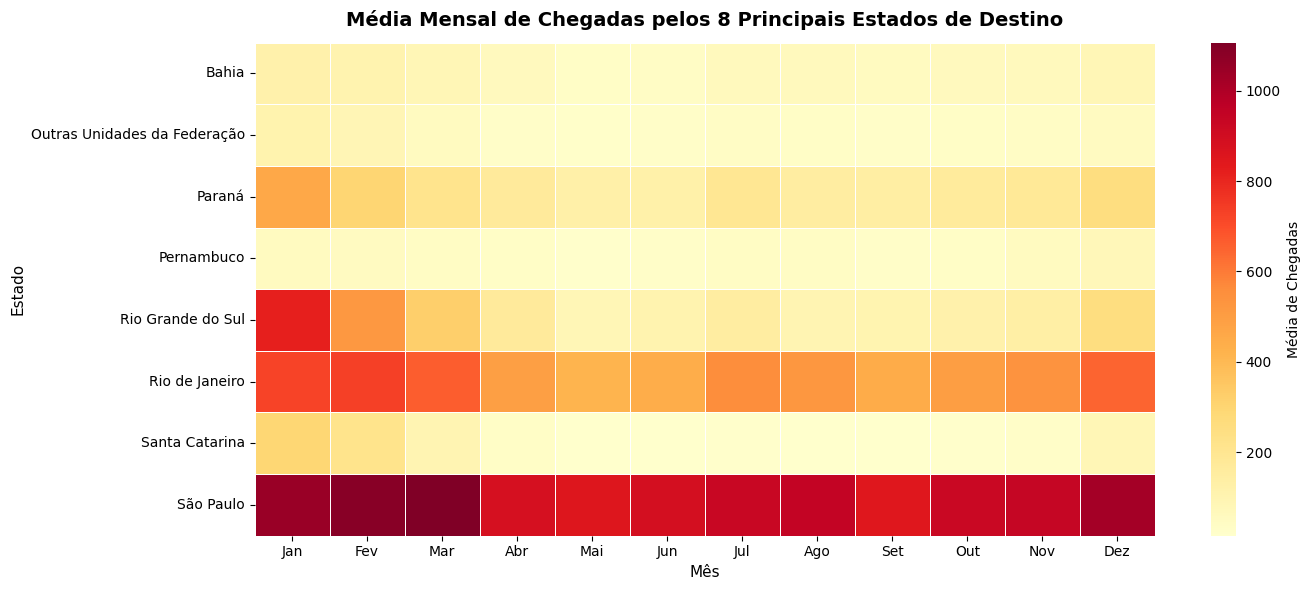

In [149]:
month_labels = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

state_month = (
    df[df['state'].isin(top_state_names)]
    .groupby(['state', 'month_num'])['arrival_count']
    .mean()
    .unstack('month_num')
)
state_month.columns = month_labels

fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(
    state_month,
    fmt='.0f',
    linewidths=0.4,
    cmap='YlOrRd',
    ax=ax,
    cbar_kws={'label': 'Média de Chegadas'},
)

ax.set_title(
    f'Média Mensal de Chegadas pelos {TOP_N} Principais Estados de Destino',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Mês', fontsize=11)
ax.set_ylabel('Estado', fontsize=11)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()

#### Região de Chegada


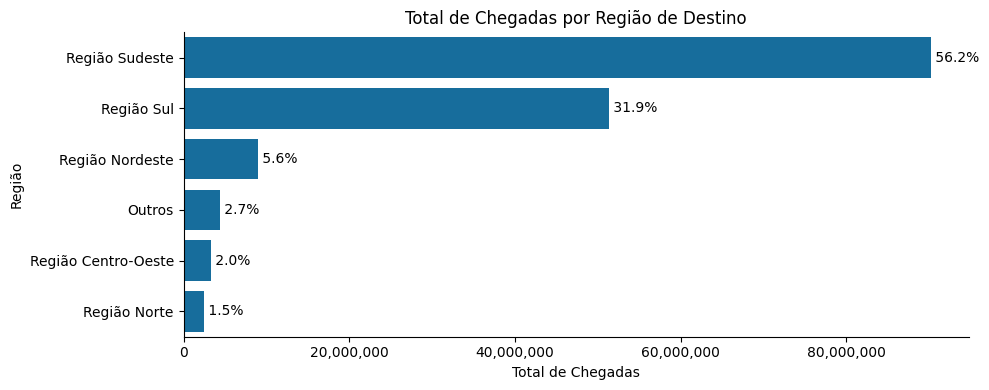

In [150]:
region_totals = pd.DataFrame(
    df.groupby('state_region')['arrival_count'].sum().sort_values(ascending=False)
)
region_totals['percentage'] = (
    region_totals['arrival_count'] / region_totals['arrival_count'].sum()
) * 100

plt.figure(figsize=(10, 4))

sns.barplot(x=region_totals['arrival_count'], y=region_totals.index)
plt.title('Total de Chegadas por Região de Destino')
plt.xlabel('Total de Chegadas')
plt.ylabel('Região')

ax = plt.gca()
for i, (count, pct) in enumerate(
    zip(region_totals['arrival_count'], region_totals['percentage'])
):
    ax.text(count, i, f' {pct:.1f}%', va='center', ha='left')

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()

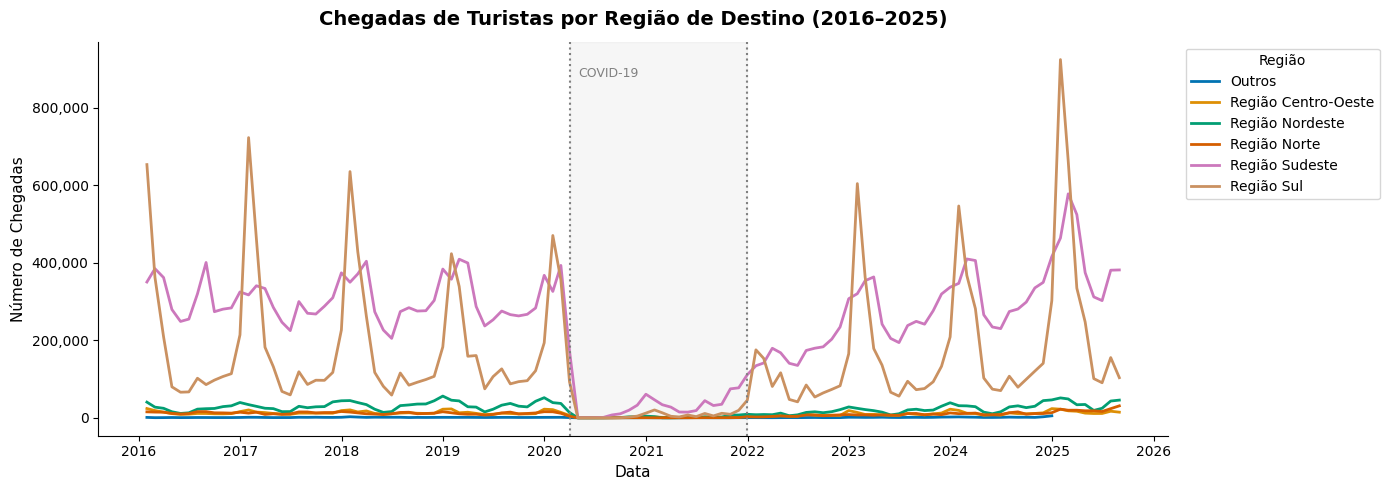

In [151]:
region_time = (
    df[df.index.year >= 2016]
    .groupby(['year_month', 'state_region'], as_index=False)['arrival_count']
    .sum()
)

fig, ax = plt.subplots(figsize=(14, 5))

sns.lineplot(
    data=region_time,
    x='year_month',
    y='arrival_count',
    hue='state_region',
    linewidth=2,
    ax=ax,
)

ax.axvline(COVID_START, color='gray', linestyle=':', linewidth=1.5, label='_nolegend_')
ax.axvline(COVID_END, color='gray', linestyle=':', linewidth=1.5, label='_nolegend_')
ax.axvspan(COVID_START, COVID_END, alpha=0.07, color='gray')

y_max = region_time['arrival_count'].max()
ax.text(
    COVID_START + pd.Timedelta(days=30),
    y_max * 0.95,
    'COVID-19',
    fontsize=9,
    color='gray',
)

ax.set_title(
    f'Chegadas de Turistas por Região de Destino (2016–{df.index.year.max()})',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Data', fontsize=11)
ax.set_ylabel('Número de Chegadas', fontsize=11)
ax.legend(title='Região', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=True)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()


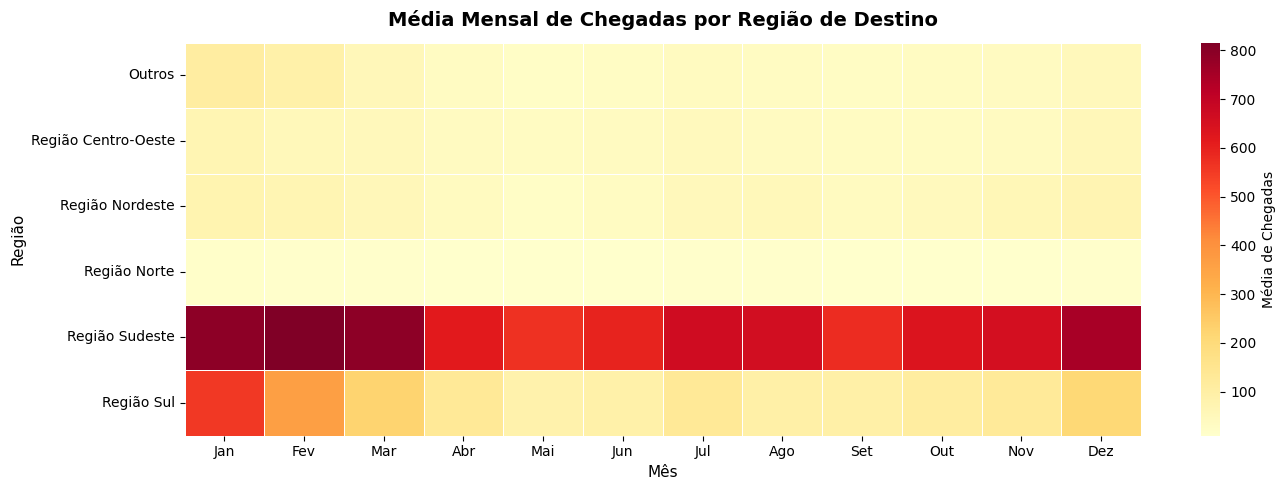

In [152]:
month_labels = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

region_month = (
    df
    .groupby(['state_region', 'month_num'])['arrival_count']
    .mean()
    .unstack('month_num')
)
region_month.columns = month_labels

fig, ax = plt.subplots(figsize=(14, 5))

sns.heatmap(
    region_month,
    fmt='.0f',
    linewidths=0.4,
    cmap='YlOrRd',
    ax=ax,
    cbar_kws={'label': 'Média de Chegadas'},
)

ax.set_title(
    'Média Mensal de Chegadas por Região de Destino',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Mês', fontsize=11)
ax.set_ylabel('Região', fontsize=11)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()

### País de Origem / Subdivisão Cultural


#### País de Origem


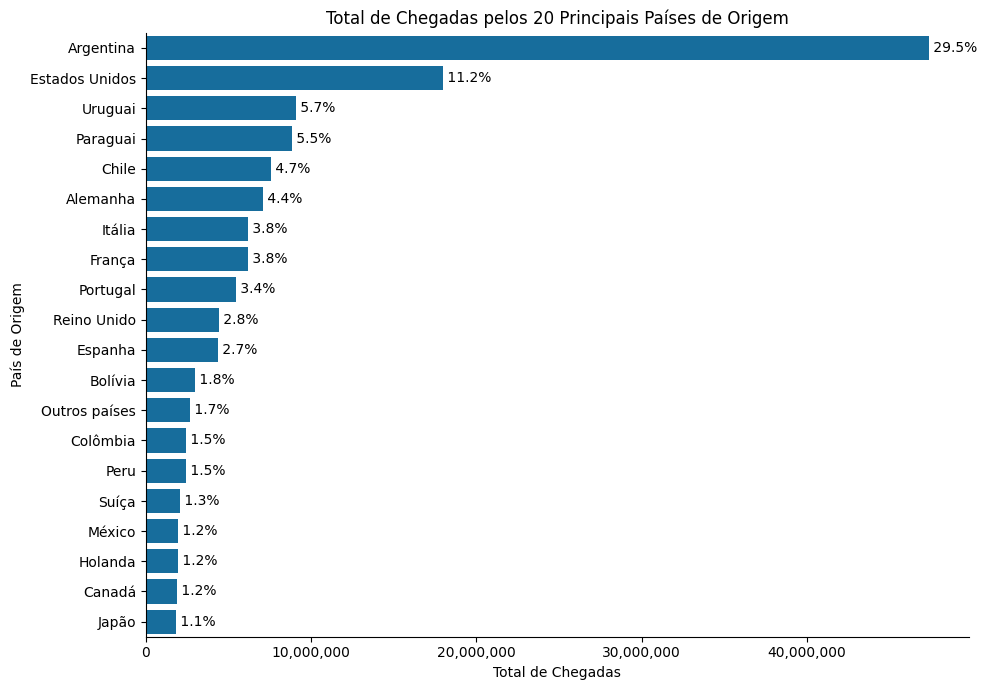

In [153]:
TOP_N_COUNTRIES = 20

top_countries = pd.DataFrame(
    df.groupby('origin_country')['arrival_count'].sum().nlargest(TOP_N_COUNTRIES)
)
top_countries['percentage'] = (
    top_countries['arrival_count']
    / df.groupby('origin_country')['arrival_count'].sum().sum()
) * 100

plt.figure(figsize=(10, 7))

sns.barplot(x=top_countries['arrival_count'], y=top_countries.index)
plt.title(f'Total de Chegadas pelos {TOP_N_COUNTRIES} Principais Países de Origem')
plt.xlabel('Total de Chegadas')
plt.ylabel('País de Origem')

ax = plt.gca()
for i, (count, pct) in enumerate(
    zip(top_countries['arrival_count'], top_countries['percentage'])
):
    ax.text(count, i, f' {pct:.1f}%', va='center', ha='left')

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()

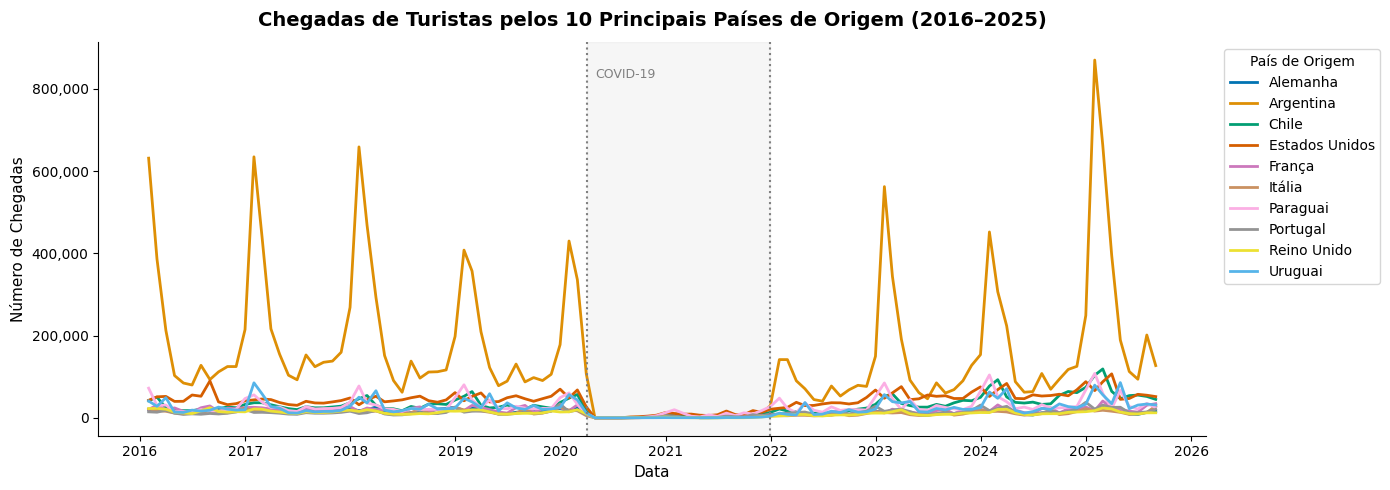

In [154]:
TOP_N_COUNTRIES = 10

top_country_names = (
    df
    .groupby('origin_country')['arrival_count']
    .sum()
    .nlargest(TOP_N_COUNTRIES)
    .index.tolist()
)

country_time = (
    df[df['origin_country'].isin(top_country_names) & (df.index.year >= 2016)]
    .groupby(['year_month', 'origin_country'], as_index=False)['arrival_count']
    .sum()
)

fig, ax = plt.subplots(figsize=(14, 5))

sns.lineplot(
    data=country_time,
    x='year_month',
    y='arrival_count',
    hue='origin_country',
    linewidth=2,
    ax=ax,
)

ax.axvline(COVID_START, color='gray', linestyle=':', linewidth=1.5, label='_nolegend_')
ax.axvline(COVID_END, color='gray', linestyle=':', linewidth=1.5, label='_nolegend_')
ax.axvspan(COVID_START, COVID_END, alpha=0.07, color='gray')

y_max = country_time['arrival_count'].max()
ax.text(
    COVID_START + pd.Timedelta(days=30),
    y_max * 0.95,
    'COVID-19',
    fontsize=9,
    color='gray',
)

ax.set_title(
    f'Chegadas de Turistas pelos {TOP_N_COUNTRIES} Principais Países de Origem '
    f'(2016–{df.index.year.max()})',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Data', fontsize=11)
ax.set_ylabel('Número de Chegadas', fontsize=11)
ax.legend(
    title='País de Origem', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=True
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()


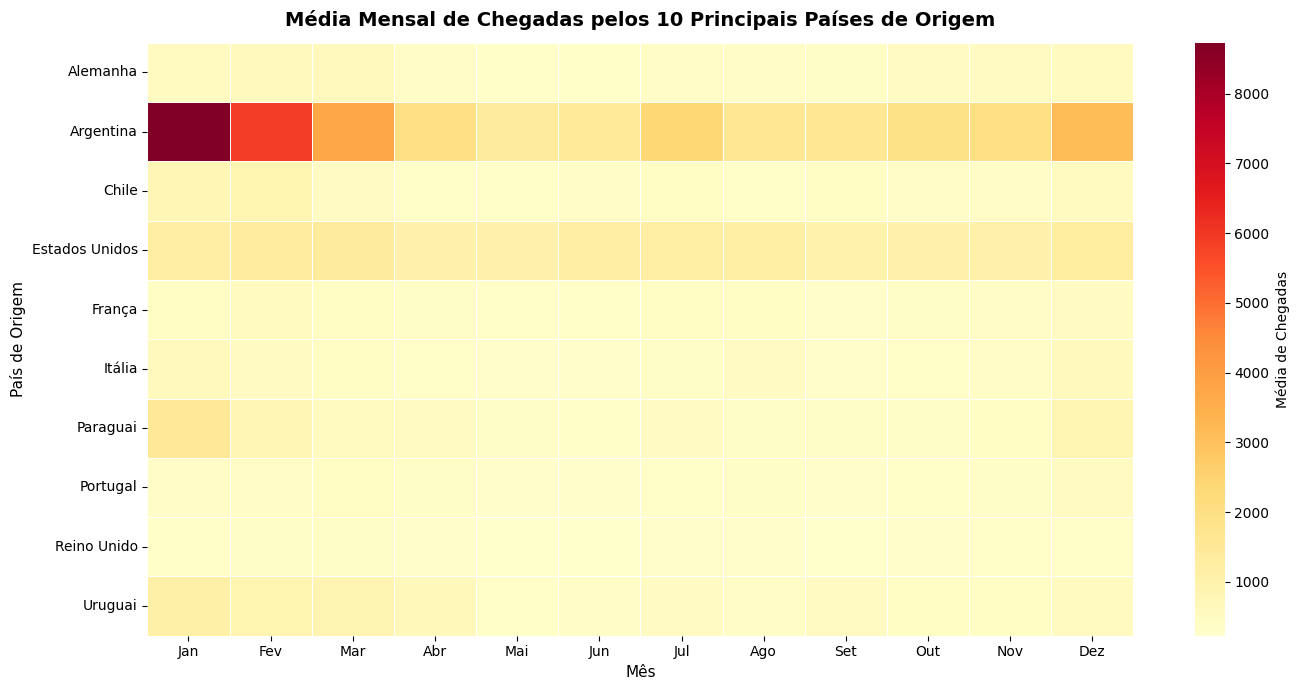

In [155]:
month_labels = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

country_month = (
    df[df['origin_country'].isin(top_country_names)]
    .groupby(['origin_country', 'month_num'])['arrival_count']
    .mean()
    .unstack('month_num')
)
country_month.columns = month_labels

fig, ax = plt.subplots(figsize=(14, 7))

sns.heatmap(
    country_month,
    fmt='.0f',
    linewidths=0.4,
    cmap='YlOrRd',
    ax=ax,
    cbar_kws={'label': 'Média de Chegadas'},
)

ax.set_title(
    f'Média Mensal de Chegadas pelos {TOP_N_COUNTRIES} Principais Países de Origem',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Mês', fontsize=11)
ax.set_ylabel('País de Origem', fontsize=11)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()

#### Subdivisão Cultural


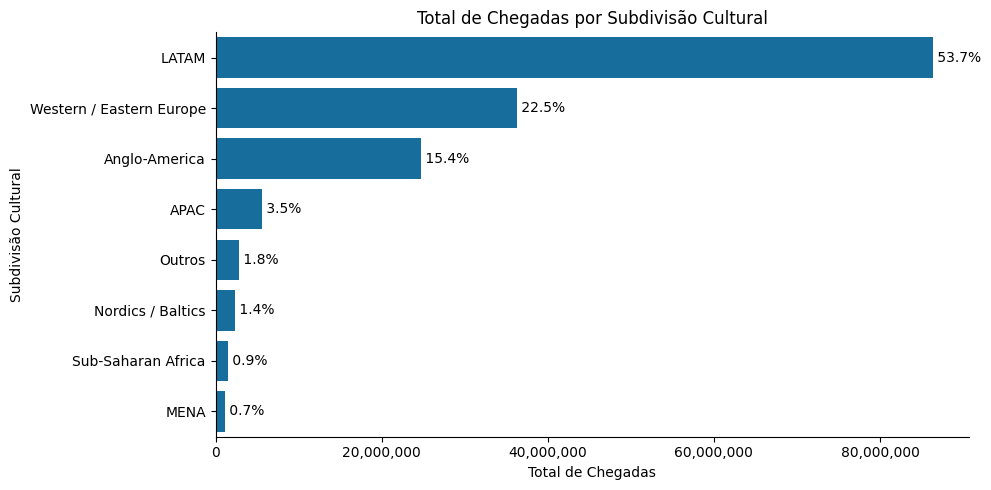

In [156]:
subdivision_totals = pd.DataFrame(
    df
    .groupby('country_cultural_subdivision')['arrival_count']
    .sum()
    .sort_values(ascending=False)
)
subdivision_totals['percentage'] = (
    subdivision_totals['arrival_count'] / subdivision_totals['arrival_count'].sum()
) * 100

plt.figure(figsize=(10, 5))

sns.barplot(x=subdivision_totals['arrival_count'], y=subdivision_totals.index)
plt.title('Total de Chegadas por Subdivisão Cultural')
plt.xlabel('Total de Chegadas')
plt.ylabel('Subdivisão Cultural')

ax = plt.gca()
for i, (count, pct) in enumerate(
    zip(subdivision_totals['arrival_count'], subdivision_totals['percentage'])
):
    ax.text(count, i, f' {pct:.1f}%', va='center', ha='left')

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()

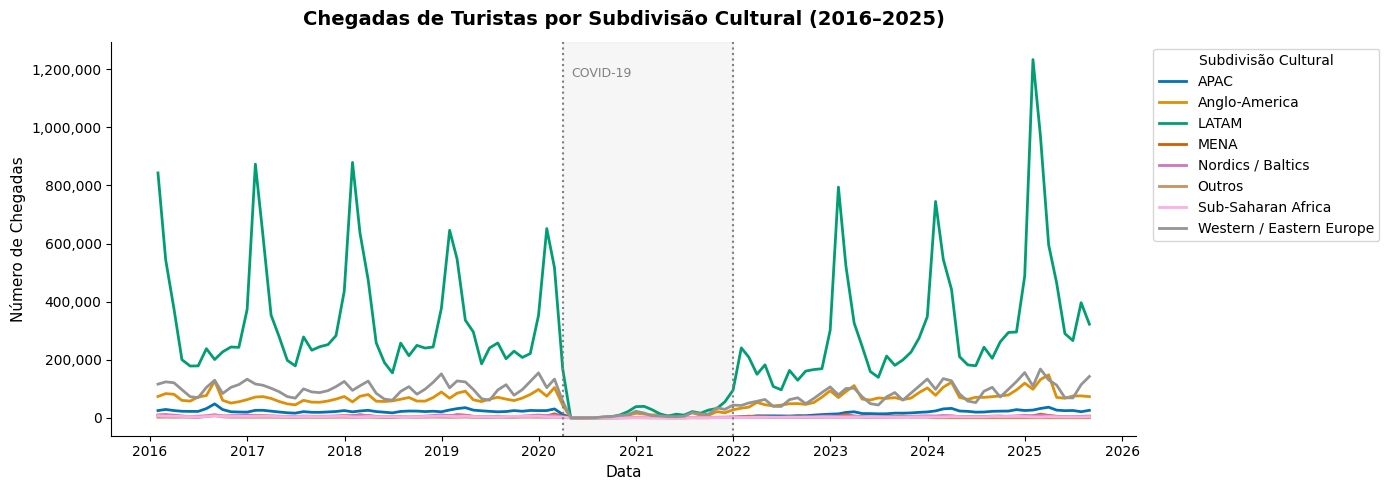

In [157]:
subdivision_time = (
    df[df.index.year >= 2016]
    .groupby(['year_month', 'country_cultural_subdivision'], as_index=False)[
        'arrival_count'
    ]
    .sum()
)

fig, ax = plt.subplots(figsize=(14, 5))

sns.lineplot(
    data=subdivision_time,
    x='year_month',
    y='arrival_count',
    hue='country_cultural_subdivision',
    linewidth=2,
    ax=ax,
)

ax.axvline(COVID_START, color='gray', linestyle=':', linewidth=1.5, label='_nolegend_')
ax.axvline(COVID_END, color='gray', linestyle=':', linewidth=1.5, label='_nolegend_')
ax.axvspan(COVID_START, COVID_END, alpha=0.07, color='gray')

y_max = subdivision_time['arrival_count'].max()
ax.text(
    COVID_START + pd.Timedelta(days=30),
    y_max * 0.95,
    'COVID-19',
    fontsize=9,
    color='gray',
)

ax.set_title(
    f'Chegadas de Turistas por Subdivisão Cultural (2016–{df.index.year.max()})',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Data', fontsize=11)
ax.set_ylabel('Número de Chegadas', fontsize=11)
ax.legend(
    title='Subdivisão Cultural',
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    frameon=True,
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()


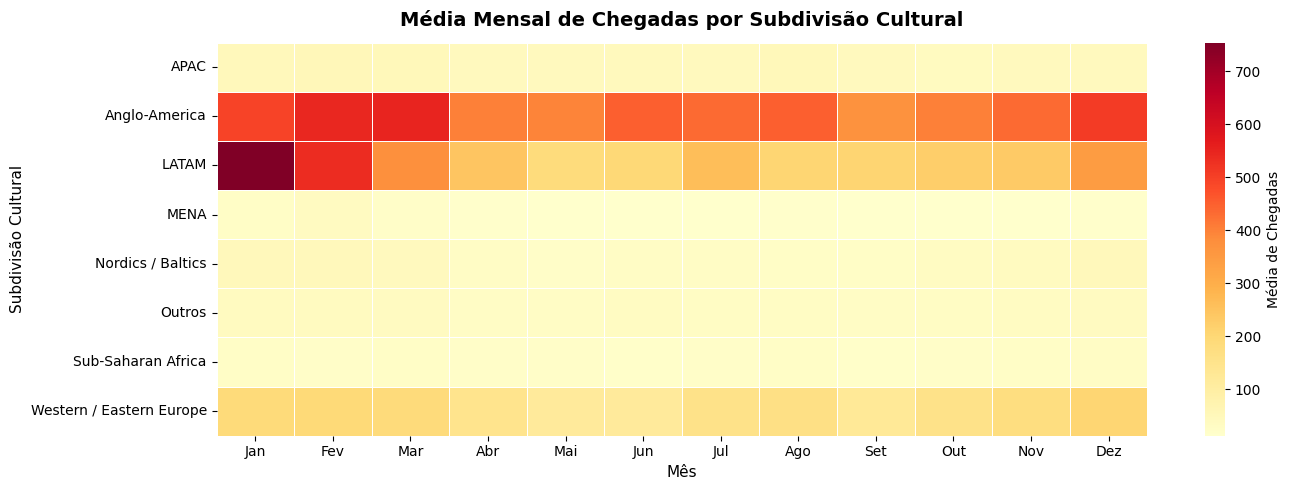

In [158]:
month_labels = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

subdivision_month = (
    df
    .groupby(['country_cultural_subdivision', 'month_num'])['arrival_count']
    .mean()
    .unstack('month_num')
)
subdivision_month.columns = month_labels

fig, ax = plt.subplots(figsize=(14, 5))

sns.heatmap(
    subdivision_month,
    fmt='.0f',
    linewidths=0.4,
    cmap='YlOrRd',
    ax=ax,
    cbar_kws={'label': 'Média de Chegadas'},
)

ax.set_title(
    'Média Mensal de Chegadas por Subdivisão Cultural',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Mês', fontsize=11)
ax.set_ylabel('Subdivisão Cultural', fontsize=11)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()

## Análise de Séries Temporais


> **Nota sobre transformações.** Uma versão anterior desta seção aplicava `np.log` à série
> antes da verificação aditiva/multiplicativa, da decomposição STL, dos testes ADF/KPSS
> e dos gráficos de FAC/FACP. O logaritmo havia sido aplicado por duas razões:
>
> 1. **Multiplicativo → aditivo.** A verificação de média–desvio padrão mostra que a amplitude
>    sazonal cresce com o nível da série (comportamento multiplicativo). Como o STL é aditivo,
>    o log era utilizado para converter `tendência × sazonalidade × erro` em `tendência + sazonalidade + erro`.
> 2. **Estabilização da variância.** O log amortece a variância dependente do nível antes de executar
>    testes de raiz unitária e avaliar autocorrelações.
>
> O log é o caso especial fixo λ = 0 da família Box-Cox, e foi aplicado sem testar previamente se a variância
> de fato varia com o nível ou se λ = 0 é a intensidade ideal. Portanto, as seções abaixo operam na **escala bruta**.
> A heterocedasticidade é então testada formalmente e o parâmetro λ é estimado pelo **método de Guerrero**
> (veja *Heterocedasticidade* e *Transformação Box-Cox*). Os resultados na escala bruta devem ser lidos levando
> isso em conta: o componente sazonal do STL absorve a amplitude crescente, e os resultados de ADF/KPSS podem
> sofrer influência da variância variante no tempo.


#### Visão Geral


In [159]:
monthly_df = df[['arrival_count']].resample('ME').sum()


def assign_period(date):
    if date < pd.Timestamp('2000-01-01'):
        return 'Legado (< 2000)'
    elif date < COVID_START:
        return 'Pré-Pandemia (2000–Mar 2020)'
    elif date <= COVID_END:
        return 'Pandemia (Abr 2020–2021)'
    else:
        return 'Pós-Pandemia (2022+)'


monthly_df['period'] = monthly_df.index.map(assign_period)
monthly_df.head()

,arrival_count,period
date,,
1989-01-31,291566.0,Legado (< 2000)
1989-02-28,197348.0,Legado (< 2000)
1989-03-31,149001.0,Legado (< 2000)
1989-04-30,84867.0,Legado (< 2000)
1989-05-31,69293.0,Legado (< 2000)


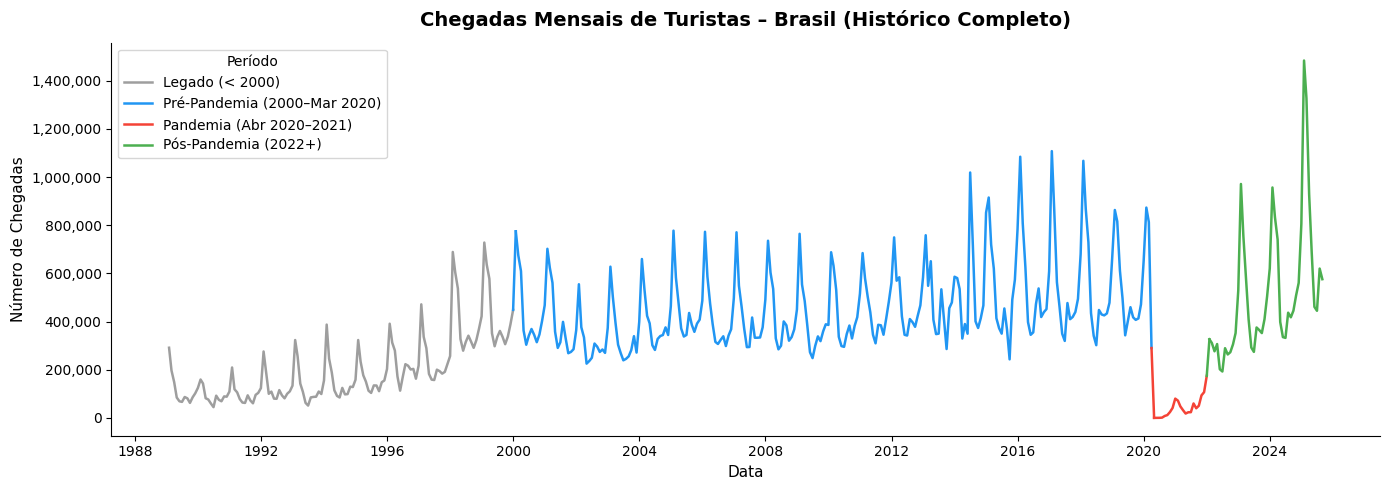

In [160]:
period_colors = {
    'Legado (< 2000)': '#9e9e9e',
    'Pré-Pandemia (2000–Mar 2020)': '#2196f3',
    'Pandemia (Abr 2020–2021)': '#f44336',
    'Pós-Pandemia (2022+)': '#4caf50',
}

fig, ax = plt.subplots(figsize=(14, 5))

for period, color in period_colors.items():
    segment = monthly_df[monthly_df['period'] == period]
    if segment.empty:
        continue
    ax.plot(
        segment.index,
        segment['arrival_count'],
        color=color,
        linewidth=1.8,
        label=period,
    )

# stitch consecutive segments so there are no visual gaps at boundaries
for i in range(len(monthly_df) - 1):
    curr, nxt = monthly_df.iloc[i], monthly_df.iloc[i + 1]
    if curr['period'] != nxt['period']:
        ax.plot(
            [monthly_df.index[i], monthly_df.index[i + 1]],
            [curr['arrival_count'], nxt['arrival_count']],
            color=period_colors[nxt['period']],
            linewidth=1.8,
        )

ax.set_title(
    'Chegadas Mensais de Turistas – Brasil (Histórico Completo)',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Data', fontsize=11)
ax.set_ylabel('Número de Chegadas', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='Período', frameon=True)
sns.despine()
plt.tight_layout()


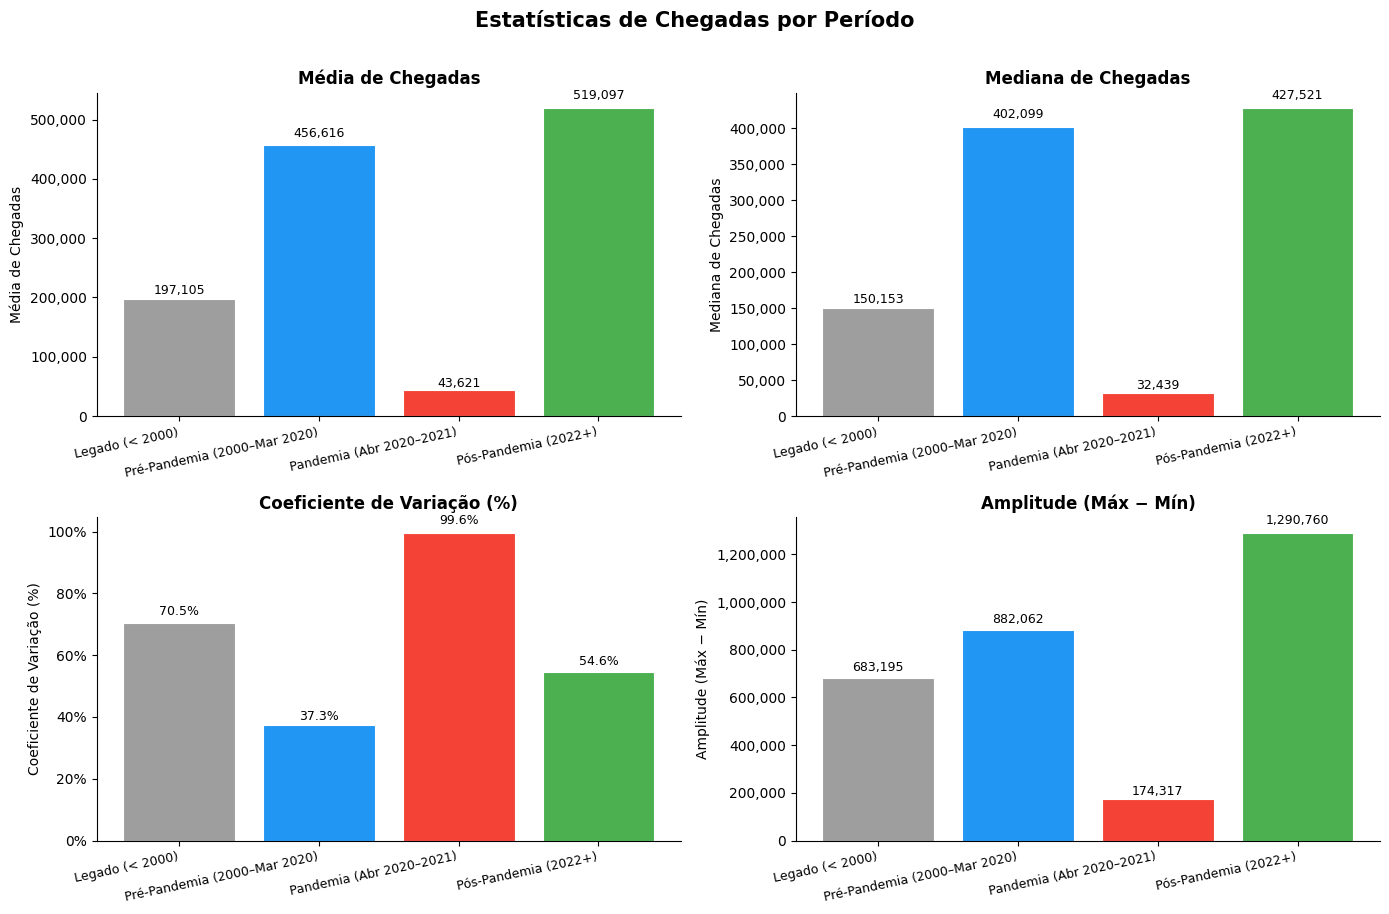

In [161]:
period_order = [
    'Legado (< 2000)',
    'Pré-Pandemia (2000–Mar 2020)',
    'Pandemia (Abr 2020–2021)',
    'Pós-Pandemia (2022+)',
]
period_colors_list = [period_colors[p] for p in period_order]

period_stats = (
    monthly_df
    .groupby('period')['arrival_count']
    .agg(
        mean='mean',
        median='median',
        cv=lambda x: x.std() / x.mean() * 100,
        range=lambda x: x.max() - x.min(),
    )
    .reindex(period_order)
)

metrics = [
    ('mean', 'Média de Chegadas', lambda v: f'{int(v):,}'),
    ('median', 'Mediana de Chegadas', lambda v: f'{int(v):,}'),
    ('cv', 'Coeficiente de Variação (%)', lambda v: f'{v:.1f}%'),
    ('range', 'Amplitude (Máx − Mín)', lambda v: f'{int(v):,}'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Estatísticas de Chegadas por Período', fontsize=15, fontweight='bold', y=1.01)

for ax, (col, title, fmt) in zip(axes.flat, metrics):
    bars = ax.bar(
        range(len(period_order)),
        period_stats[col],
        color=period_colors_list,
        edgecolor='white',
        linewidth=0.8,
    )
    for bar, val in zip(bars, period_stats[col]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.02,
            fmt(val),
            ha='center',
            va='bottom',
            fontsize=9,
        )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(title, fontsize=10)
    ax.set_xticks(range(len(period_order)))
    ax.set_xticklabels(period_order, rotation=12, ha='right', fontsize=9)
    is_cv = col == 'cv'
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(
            lambda x, _, _is_cv=is_cv: f'{x:.0f}%' if _is_cv else f'{x:,.0f}'
        )
    )
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

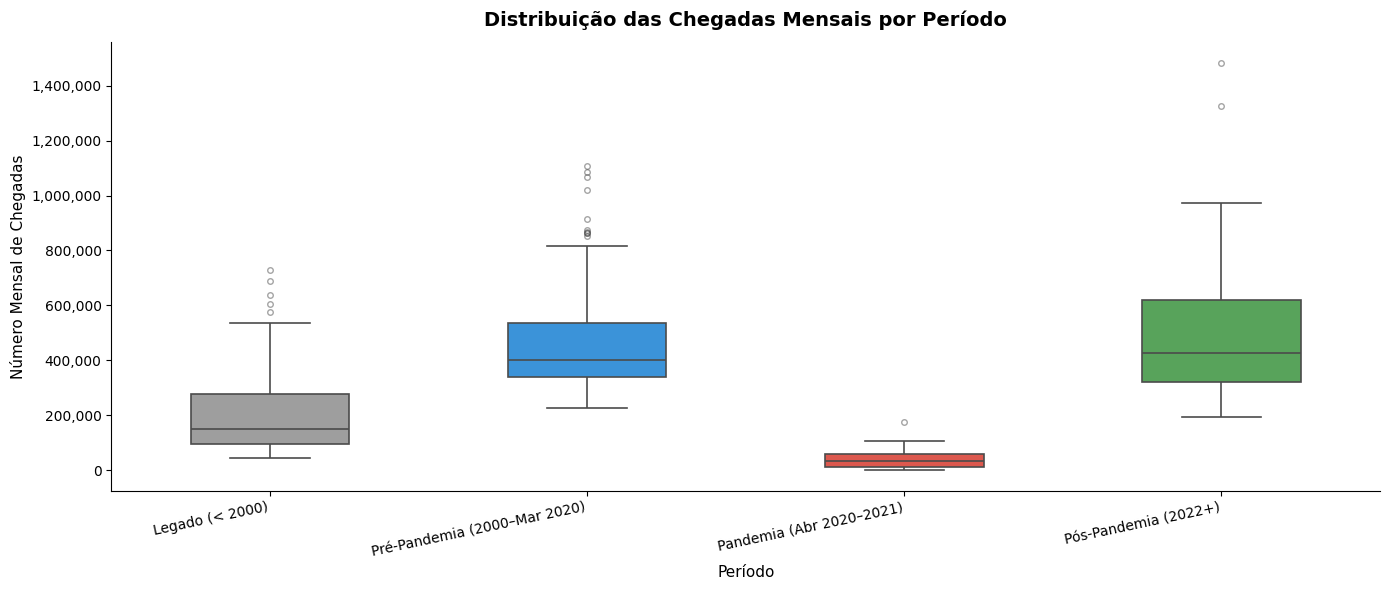

In [162]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=monthly_df,
    x='period',
    y='arrival_count',
    hue='period',
    order=period_order,
    palette=period_colors,
    width=0.5,
    linewidth=1.2,
    flierprops=dict(marker='o', markersize=4, alpha=0.5),
    legend=False,
    ax=ax,
)

ax.set_title(
    'Distribuição das Chegadas Mensais por Período', fontsize=14, fontweight='bold', pad=12
)
ax.set_xlabel('Período', fontsize=11)
ax.set_ylabel('Número Mensal de Chegadas', fontsize=11)
ax.set_xticks(range(len(period_order)))
ax.set_xticklabels(period_order, rotation=12, ha='right', fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()
plt.show()

#### Tendência


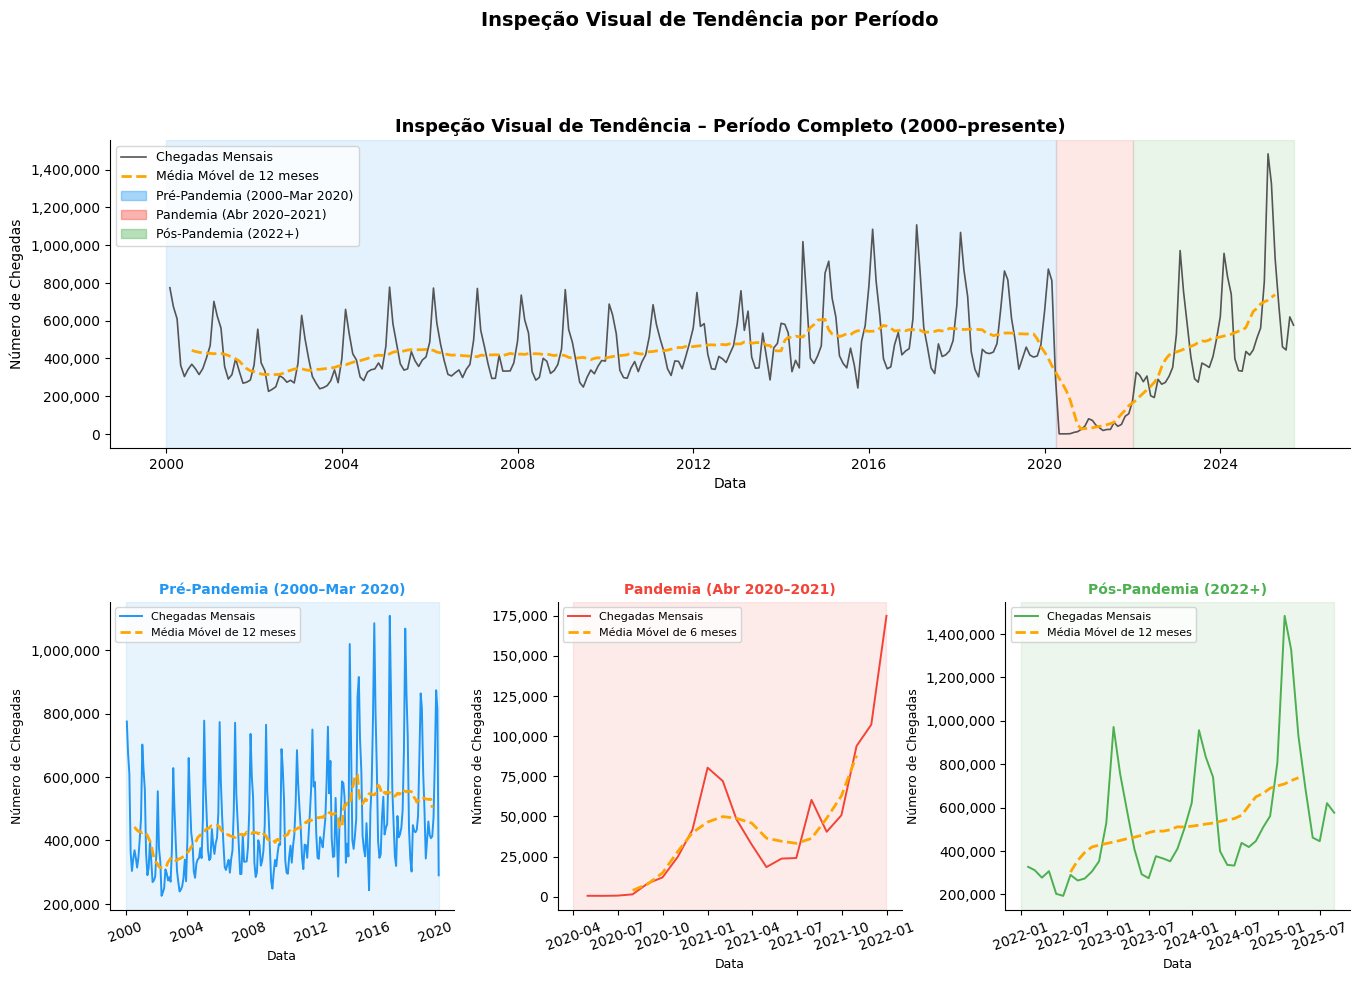

In [163]:
import matplotlib.patches as mpatches

trend_periods = [
    (
        'Pré-Pandemia (2000–Mar 2020)',
        pd.Timestamp('2000-01-01'),
        COVID_START - pd.Timedelta(days=1),
    ),
    ('Pandemia (Abr 2020–2021)', COVID_START, COVID_END),
    ('Pós-Pandemia (2022+)', pd.Timestamp('2022-01-01'), monthly_df.index[-1]),
]

post_2000 = monthly_df[monthly_df['period'] != 'Legado (< 2000)']

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, hspace=0.5, wspace=0.3)

# ── top: full post-2000 spanning all 3 columns ────────────────────────────────
ax_full = fig.add_subplot(gs[0, :])

ax_full.plot(
    post_2000.index,
    post_2000['arrival_count'],
    color='#555555',
    linewidth=1.2,
    label='Chegadas Mensais',
)

rolling_full = post_2000['arrival_count'].rolling(12, center=True).mean()
ax_full.plot(
    post_2000.index,
    rolling_full,
    color='orange',
    linewidth=2,
    linestyle='--',
    label='Média Móvel de 12 meses',
)

for period, start, end in trend_periods:
    ax_full.axvspan(start, end, alpha=0.12, color=period_colors[period])

line_handles, _ = ax_full.get_legend_handles_labels()
span_handles = [
    mpatches.Patch(color=period_colors[p], alpha=0.4, label=p)
    for p, _, _ in trend_periods
]
ax_full.legend(handles=line_handles + span_handles, fontsize=9, frameon=True)
ax_full.set_title(
    'Inspeção Visual de Tendência – Período Completo (2000–presente)',
    fontsize=13,
    fontweight='bold',
)
ax_full.set_xlabel('Data', fontsize=10)
ax_full.set_ylabel('Número de Chegadas', fontsize=10)
ax_full.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine(ax=ax_full)

# ── bottom: one subplot per period ───────────────────────────────────────────
for col_idx, (period, start, end) in enumerate(trend_periods):
    ax = fig.add_subplot(gs[1, col_idx])
    color = period_colors[period]

    segment = monthly_df[(monthly_df.index >= start) & (monthly_df.index <= end)]

    ax.plot(
        segment.index,
        segment['arrival_count'],
        color=color,
        linewidth=1.4,
        label='Chegadas Mensais',
    )
    ax.axvspan(start, end, alpha=0.1, color=color)

    # pandemic (~24 obs) is too short for a 12-month centered window
    window = 6 if len(segment) < 36 else 12
    rolling = segment['arrival_count'].rolling(window, center=True).mean()
    ax.plot(
        segment.index,
        rolling,
        color='orange',
        linewidth=2,
        linestyle='--',
        label=f'Média Móvel de {window} meses',
    )

    ax.set_title(period, fontsize=10, fontweight='bold', color=color)
    ax.set_xlabel('Data', fontsize=9)
    ax.set_ylabel('Número de Chegadas', fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.legend(fontsize=8, frameon=True)
    ax.tick_params(axis='x', rotation=20)
    sns.despine(ax=ax)

plt.suptitle(
    'Inspeção Visual de Tendência por Período', fontsize=14, fontweight='bold', y=1.01
)
plt.show()


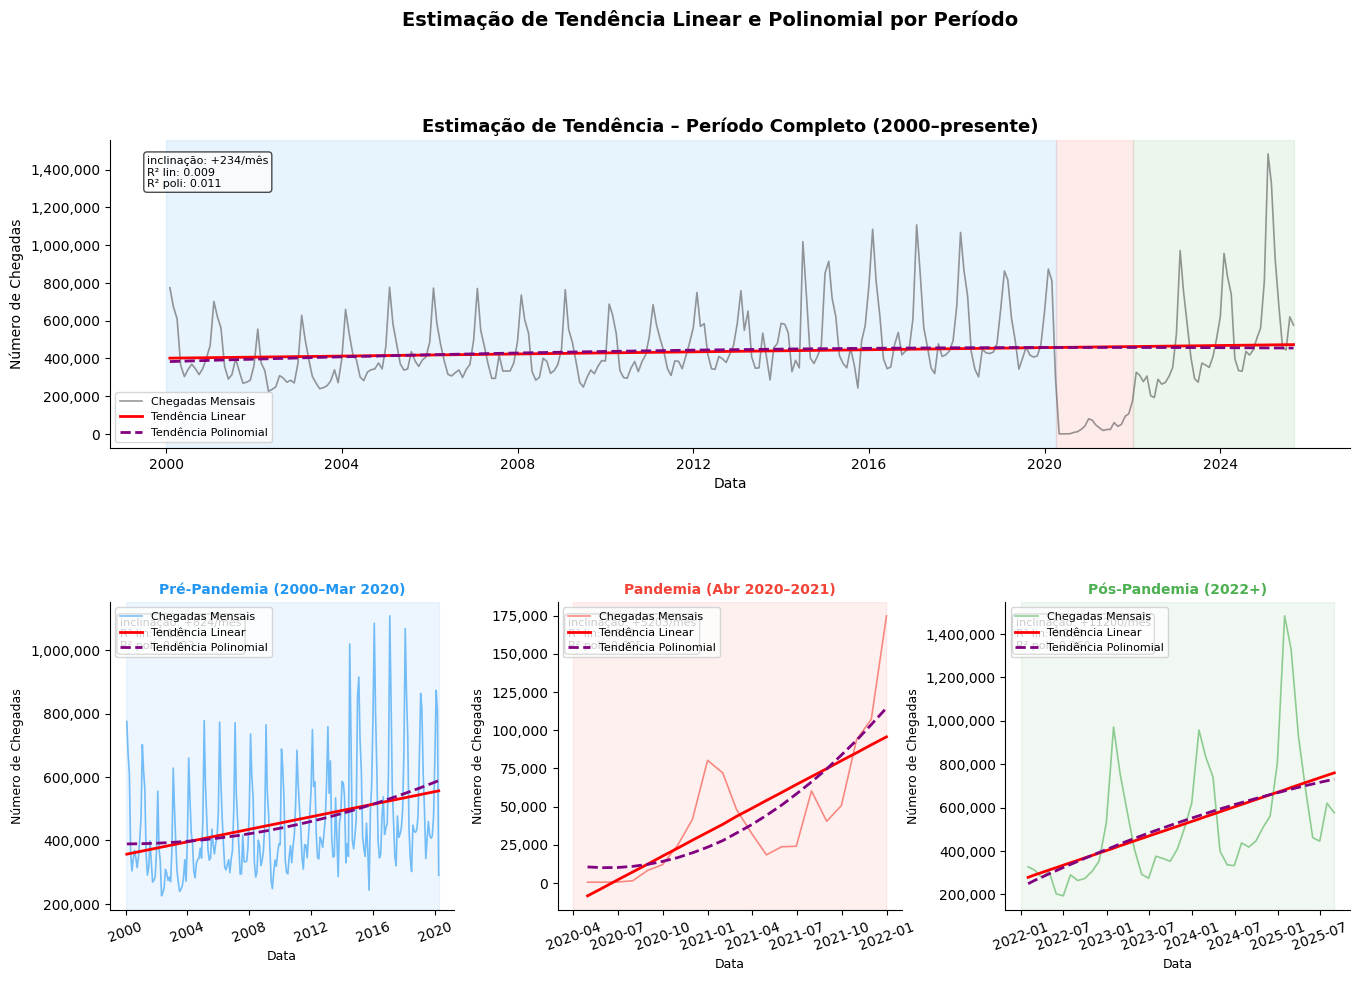

                                 Inclinação Linear (chegadas/mês) R² Linear R² Polinomial
Período                                                                                  
Período Completo (2000–presente)                           +233.5    0.0094        0.0108
Pré-Pandemia (2000–Mar 2020)                               +823.9    0.1156        0.1230
Pandemia (Abr 2020–2021)                                  +5202.9    0.5520        0.6050
Pós-Pandemia (2022+)                                     +11199.7    0.2576        0.2601


In [164]:
def fit_trends(series):
    """Return (lin_model, poly_model, poly_features, t_index, stats_dict)."""
    t = np.arange(len(series)).reshape(-1, 1)
    y = series.values

    lin = LinearRegression().fit(t, y)

    pf = PolynomialFeatures(degree=2)
    poly = LinearRegression().fit(pf.fit_transform(t), y)

    stats = {
        'slope': lin.coef_[0],
        'r2_lin': lin.score(t, y),
        'r2_poly': poly.score(pf.fit_transform(t), y),
    }
    return lin, poly, pf, t, stats


def plot_trend_panel(ax, segment, period, color):
    lin, poly, pf, t, stats = fit_trends(segment['arrival_count'])

    ax.plot(
        segment.index,
        segment['arrival_count'],
        color=color,
        linewidth=1.2,
        alpha=0.6,
        label='Chegadas Mensais',
    )
    ax.plot(
        segment.index, lin.predict(t), color='red', linewidth=2, label='Tendência Linear'
    )
    ax.plot(
        segment.index,
        poly.predict(pf.fit_transform(t)),
        color='purple',
        linewidth=2,
        linestyle='--',
        label='Tendência Polinomial',
    )

    ax.annotate(
        f'inclinação: {stats["slope"]:+.0f}/mês\nR² lin: {stats["r2_lin"]:.3f}\nR² poli: {stats["r2_poly"]:.3f}',
        xy=(0.03, 0.95),
        xycoords='axes fraction',
        va='top',
        fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7),
    )
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.legend(fontsize=8, frameon=True)
    sns.despine(ax=ax)
    return stats


# ── build figure ─────────────────────────────────────────────────────────────
post_2000 = monthly_df[monthly_df['period'] != 'Legado (< 2000)']

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, hspace=0.5, wspace=0.3)

# top: full post-2000
ax_full = fig.add_subplot(gs[0, :])
full_stats = plot_trend_panel(ax_full, post_2000, 'Full Period', '#555555')

for period, start, end in trend_periods:
    ax_full.axvspan(start, end, alpha=0.1, color=period_colors[period])

ax_full.set_title(
    'Estimação de Tendência – Período Completo (2000–presente)', fontsize=13, fontweight='bold'
)
ax_full.set_xlabel('Data', fontsize=10)
ax_full.set_ylabel('Número de Chegadas', fontsize=10)

# bottom: one per period
all_stats = [('Período Completo (2000–presente)', full_stats)]

for col_idx, (period, start, end) in enumerate(trend_periods):
    ax = fig.add_subplot(gs[1, col_idx])
    color = period_colors[period]

    segment = monthly_df[(monthly_df.index >= start) & (monthly_df.index <= end)]
    stats = plot_trend_panel(ax, segment, period, color)
    ax.axvspan(start, end, alpha=0.08, color=color)
    ax.set_title(period, fontsize=10, fontweight='bold', color=color)
    ax.set_xlabel('Data', fontsize=9)
    ax.set_ylabel('Número de Chegadas', fontsize=9)
    ax.tick_params(axis='x', rotation=20)

    all_stats.append((period, stats))

plt.suptitle(
    'Estimação de Tendência Linear e Polinomial por Período',
    fontsize=14,
    fontweight='bold',
    y=1.01,
)
plt.show()

# ── summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame(
    [
        (p, f'{s["slope"]:+.1f}', f'{s["r2_lin"]:.4f}', f'{s["r2_poly"]:.4f}')
        for p, s in all_stats
    ],
    columns=['Período', 'Inclinação Linear (chegadas/mês)', 'R² Linear', 'R² Polinomial'],
).set_index('Período')

print(summary.to_string())


##### Testes Estatísticos de Tendência

As verificações visuais e de regressão acima são complementadas com testes não-paramétricos
encapsulados por `check_trend` e `check_deterministic_trend` (Joseph & Tackes, *Modern Time
Series Forecasting with Python* 2E, `src/transforms/stationary_utils.py`):

- **Kendall's τ**: correlação de postos entre a série e o tempo.
- **Mann-Kendall**: teste de tendência monotônica com inclinação de Sen. Para séries com menos de 50
  pontos, a função aplica a variante com pré-branqueamento para mitigar o efeito da autocorrelação.
- **Mann-Kendall Sazonal (m = 12)**: executa o teste dentro de cada mês do calendário, evitando que
  o ciclo sazonal mascare ou infle a tendência. A inclinação é expressa em chegadas por ano.
- **Tendência determinística**: ADF apenas com constante (`c`) vs constante + tendência (`ct`). Se a
  série for não-estacionária sob `c`, mas estacionária sob `ct`, a tendência é determinística e a
  remoção de tendência linear é suficiente. Caso contrário, é necessária diferenciação.


In [165]:
# Helpers `check_trend` / `check_deterministic_trend` from Joseph & Tackes,
# "Modern Time Series Forecasting with Python" 2E — src/transforms/stationary_utils.py

period_series = {
    'Período Completo (2000–presente)': post_2000['arrival_count'],
    **{
        period: monthly_df.loc[
            (monthly_df.index >= start) & (monthly_df.index <= end), 'arrival_count'
        ]
        for period, start, end in trend_periods
    },
}
period_series_colors = {
    'Período Completo (2000–presente)': '#555555',
    **{p: period_colors[p] for p, _, _ in trend_periods},
}

trend_rows = []
for label, series in period_series.items():
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        kt = check_trend(series, confidence=0.05)
        mk_res = check_trend(series, confidence=0.05, mann_kendall=True)
        smk = check_trend(
            series, confidence=0.05, mann_kendall=True, seasonal_period=SEASONAL_PERIOD
        )
        det = check_deterministic_trend(series, confidence=0.05)

    trend_rows.append({
        'Period': label,
        'n': len(series),
        'Kendall τ': f'{kt.slope:+.3f}',
        'Kendall p': f'{kt.p_value:.4f}',
        'Kendall trend': '✓' if kt.trend else '✗',
        'MK test': type(mk_res).__name__.replace('_', ' '),
        "MK Sen's slope (/mo)": f'{mk_res.slope:+,.0f}',
        'MK p': f'{mk_res.p_value:.4f}',
        'MK trend': '✓' if mk_res.trend else '✗',
        'Seasonal MK slope (/yr)': f'{smk.slope:+,.0f}',
        'Seasonal MK p': f'{smk.p_value:.4f}',
        'Seasonal MK trend': '✓' if smk.trend else '✗',
        'ADF(c) p': f'{det.adf_res.results[1]:.4f}',
        'ADF(ct) p': f'{det.adf_ct_res.results[1]:.4f}',
        'Deterministic trend': '✓' if det.deterministic_trend else '✗',
    })

trend_tests = pd.DataFrame(trend_rows).set_index('Period')

print('=' * 100)
print('TREND TESTS — Kendall τ, Mann-Kendall, Seasonal MK (m=12), ADF c vs ct')
print('H0 (Kendall / MK): no monotonic trend → reject (p < 0.05) = trend present')
print('=' * 100)
print(trend_tests.T.to_string())

TREND TESTS — Kendall τ, Mann-Kendall, Seasonal MK (m=12), ADF c vs ct
H0 (Kendall / MK): no monotonic trend → reject (p < 0.05) = trend present
Period                  Período Completo (2000–presente) Pré-Pandemia (2000–Mar 2020)                          Pandemia (Abr 2020–2021)                              Pós-Pandemia (2022+)
n                                                    308                          243                                                21                                                44
Kendall τ                                         +0.101                       +0.265                                            +0.657                                            +0.455
Kendall p                                         0.0084                       0.0000                                            0.0000                                            0.0000
Kendall trend                                          ✓                            ✓                          

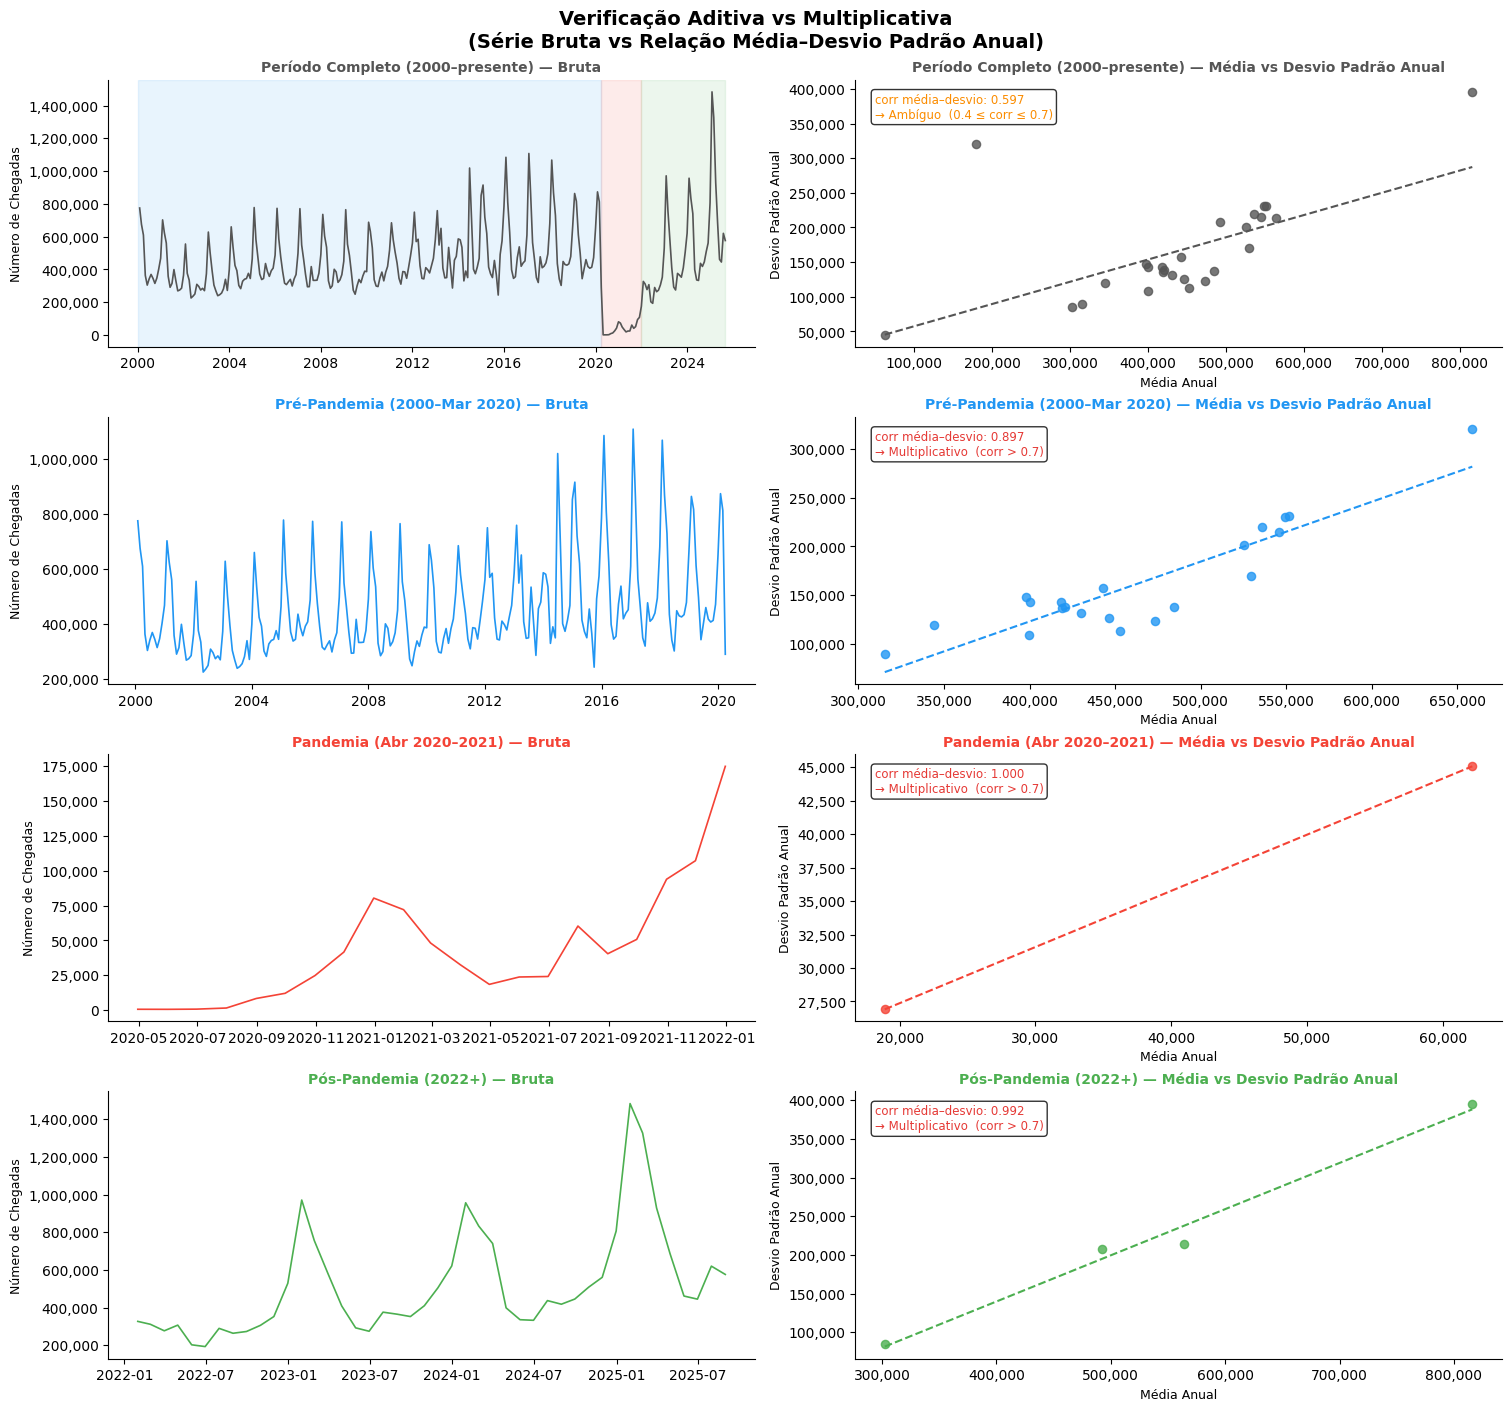

                                 Correlação Média–Desvio                      Veredito
Período                                                                               
Período Completo (2000–presente)                   0.597   Ambíguo  (0.4 ≤ corr ≤ 0.7)
Pré-Pandemia (2000–Mar 2020)                       0.897  Multiplicativo  (corr > 0.7)
Pandemia (Abr 2020–2021)                           1.000  Multiplicativo  (corr > 0.7)
Pós-Pandemia (2022+)                               0.992  Multiplicativo  (corr > 0.7)


In [166]:
def additive_or_multiplicative(segment, label, color):
    """Visual + quantitative check for decomposition type."""
    series = segment['arrival_count'].dropna()

    annual = series.resample('YE').agg(['mean', 'std']).dropna()
    corr = annual['mean'].corr(annual['std'])

    if corr > 0.7:
        verdict = 'Multiplicativo  (corr > 0.7)'
        verdict_color = '#e53935'
    elif corr < 0.4:
        verdict = 'Aditivo  (corr < 0.4)'
        verdict_color = '#1e88e5'
    else:
        verdict = 'Ambíguo  (0.4 ≤ corr ≤ 0.7)'
        verdict_color = '#fb8c00'

    return {
        'label': label,
        'corr': corr,
        'verdict': verdict,
        'verdict_color': verdict_color,
        'series': series,
        'annual': annual,
        'color': color,
    }


non_legacy_periods = [
    (
        'Pré-Pandemia (2000–Mar 2020)',
        pd.Timestamp('2000-01-01'),
        COVID_START - pd.Timedelta(days=1),
    ),
    ('Pandemia (Abr 2020–2021)', COVID_START, COVID_END),
    ('Pós-Pandemia (2022+)', pd.Timestamp('2022-01-01'), monthly_df.index[-1]),
]

post_2000 = monthly_df[monthly_df['period'] != 'Legado (< 2000)']

results = [
    additive_or_multiplicative(post_2000, 'Período Completo (2000–presente)', '#555555')
]
for period, start, end in non_legacy_periods:
    seg = monthly_df[(monthly_df.index >= start) & (monthly_df.index <= end)]
    results.append(additive_or_multiplicative(seg, period, period_colors[period]))

# ── 4 × 2 figure: raw series vs annual mean–std relationship ─────────────────
fig, axes = plt.subplots(4, 2, figsize=(15, 14), constrained_layout=True)
fig.suptitle(
    'Verificação Aditiva vs Multiplicativa\n(Série Bruta vs Relação Média–Desvio Padrão Anual)',
    fontsize=14,
    fontweight='bold',
)

for row, res in enumerate(results):
    ax_raw, ax_ms = axes[row, 0], axes[row, 1]
    color = res['color']

    ax_raw.plot(res['series'].index, res['series'], color=color, linewidth=1.2)
    ax_raw.set_title(
        f'{res["label"]} — Bruta', fontsize=10, fontweight='bold', color=color
    )
    ax_raw.set_ylabel('Número de Chegadas', fontsize=9)
    ax_raw.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    sns.despine(ax=ax_raw)

    annual = res['annual']
    ax_ms.scatter(annual['mean'], annual['std'], color=color, s=35, alpha=0.8)
    if len(annual) > 1:
        coef = np.polyfit(annual['mean'], annual['std'], 1)
        x_line = np.linspace(annual['mean'].min(), annual['mean'].max(), 50)
        ax_ms.plot(x_line, np.polyval(coef, x_line), color=color, linestyle='--')
    ax_ms.set_title(
        f'{res["label"]} — Média vs Desvio Padrão Anual',
        fontsize=10,
        fontweight='bold',
        color=color,
    )
    ax_ms.set_xlabel('Média Anual', fontsize=9)
    ax_ms.set_ylabel('Desvio Padrão Anual', fontsize=9)
    ax_ms.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax_ms.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax_ms.annotate(
        f'corr média–desvio: {res["corr"]:.3f}\n→ {res["verdict"]}',
        xy=(0.03, 0.95),
        xycoords='axes fraction',
        va='top',
        fontsize=8.5,
        color=res['verdict_color'],
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8),
    )
    sns.despine(ax=ax_ms)

    # period shading on full-period row only
    if res['label'] == 'Período Completo (2000–presente)':
        for period, start, end in non_legacy_periods:
            ax_raw.axvspan(start, end, alpha=0.1, color=period_colors[period])

plt.show()

# ── summary table ─────────────────────────────────────────────────────────────
summary_add = pd.DataFrame(
    [(r['label'], f'{r["corr"]:.3f}', r['verdict']) for r in results],
    columns=['Período', 'Correlação Média–Desvio', 'Veredito'],
).set_index('Período')

print(summary_add.to_string())

#### Sazonalidade


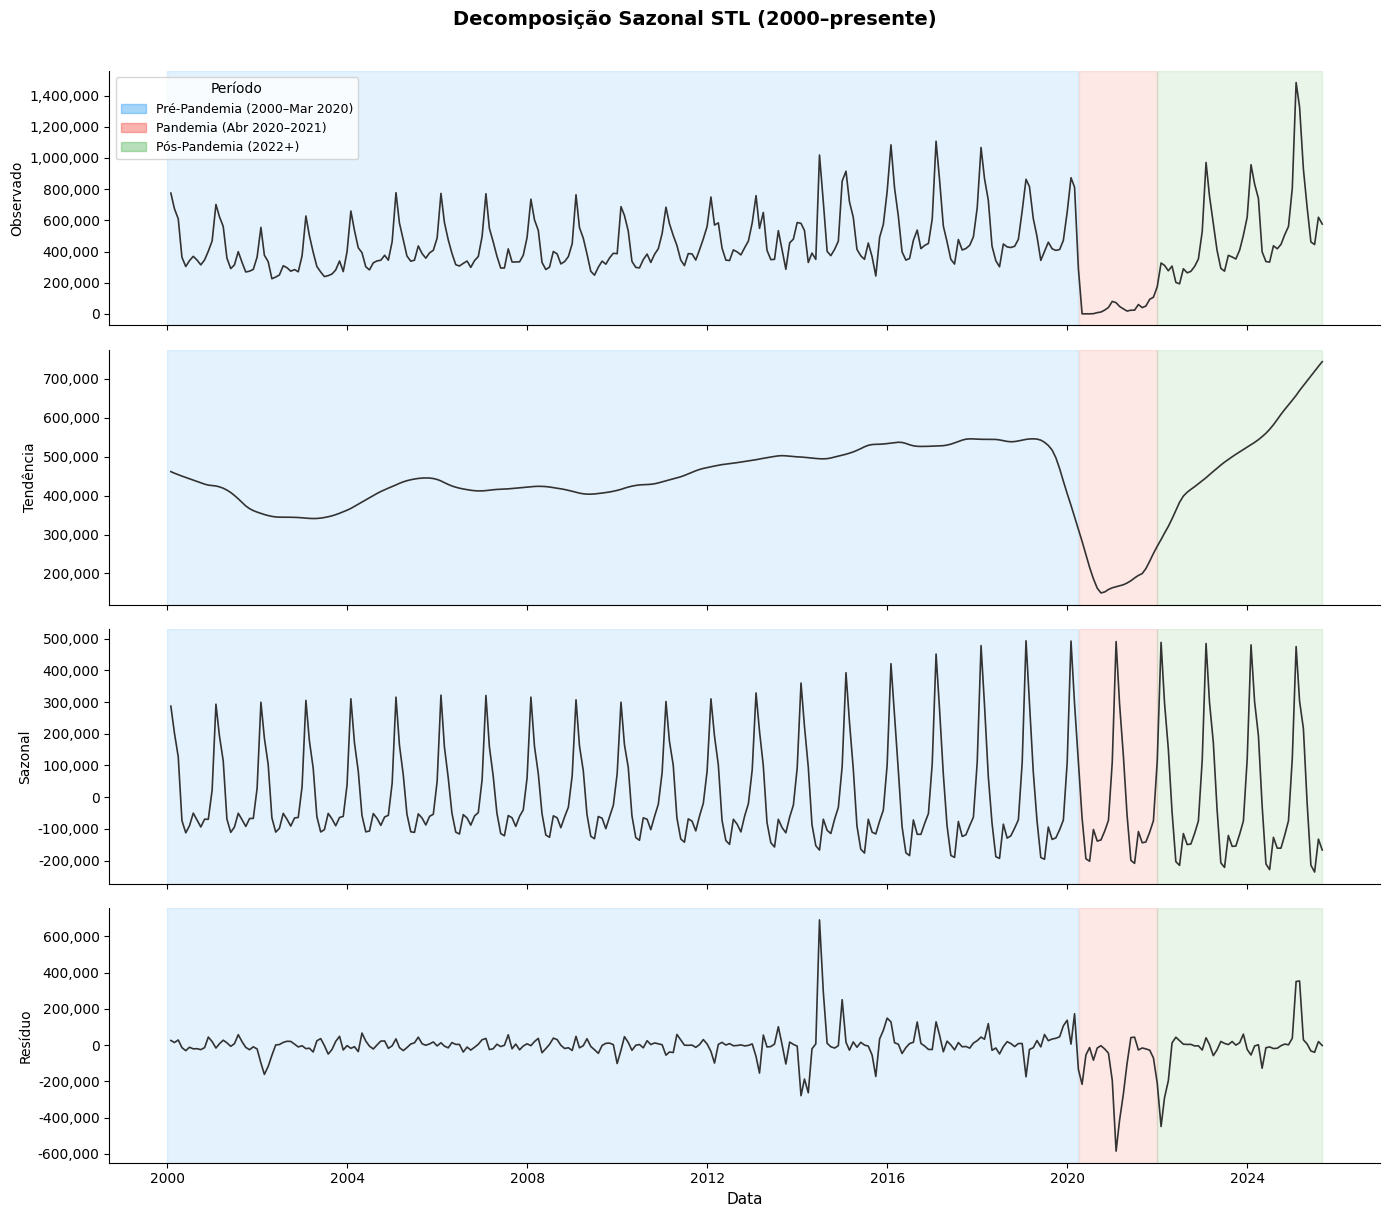

In [167]:
stl_series = monthly_df.loc[monthly_df['period'] != 'Legado (< 2000)', 'arrival_count']

stl = STL(stl_series, period=12, seasonal=13, robust=True)
result = stl.fit()

components = [
    ('observed', 'Observado', result.observed),
    ('trend', 'Tendência', result.trend),
    ('seasonal', 'Sazonal', result.seasonal),
    ('resid', 'Resíduo', result.resid),
]

period_spans = [
    (
        'Pré-Pandemia (2000–Mar 2020)',
        pd.Timestamp('2000-01-01'),
        COVID_START - pd.Timedelta(days=1),
    ),
    ('Pandemia (Abr 2020–2021)', COVID_START, COVID_END),
    ('Pós-Pandemia (2022+)', pd.Timestamp('2022-01-01'), stl_series.index[-1]),
]

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
fig.suptitle(
    'Decomposição Sazonal STL (2000–presente)',
    fontsize=14,
    fontweight='bold',
    y=1.01,
)

for ax, (_, label, component) in zip(axes, components):
    ax.plot(component.index, component.values, color='#333333', linewidth=1.2)

    for period, start, end in period_spans:
        ax.axvspan(start, end, alpha=0.12, color=period_colors[period], label=period)

    ax.set_ylabel(label, fontsize=10)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    sns.despine(ax=ax)

# single shared legend on the top subplot
handles = [
    plt.Rectangle((0, 0), 1, 1, color=period_colors[p], alpha=0.4)
    for p in [
        'Pré-Pandemia (2000–Mar 2020)',
        'Pandemia (Abr 2020–2021)',
        'Pós-Pandemia (2022+)',
    ]
]
labels = [
    'Pré-Pandemia (2000–Mar 2020)',
    'Pandemia (Abr 2020–2021)',
    'Pós-Pandemia (2022+)',
]
axes[0].legend(
    handles, labels, title='Período', loc='upper left', frameon=True, fontsize=9
)

axes[-1].set_xlabel('Data', fontsize=11)
plt.tight_layout()
plt.show()


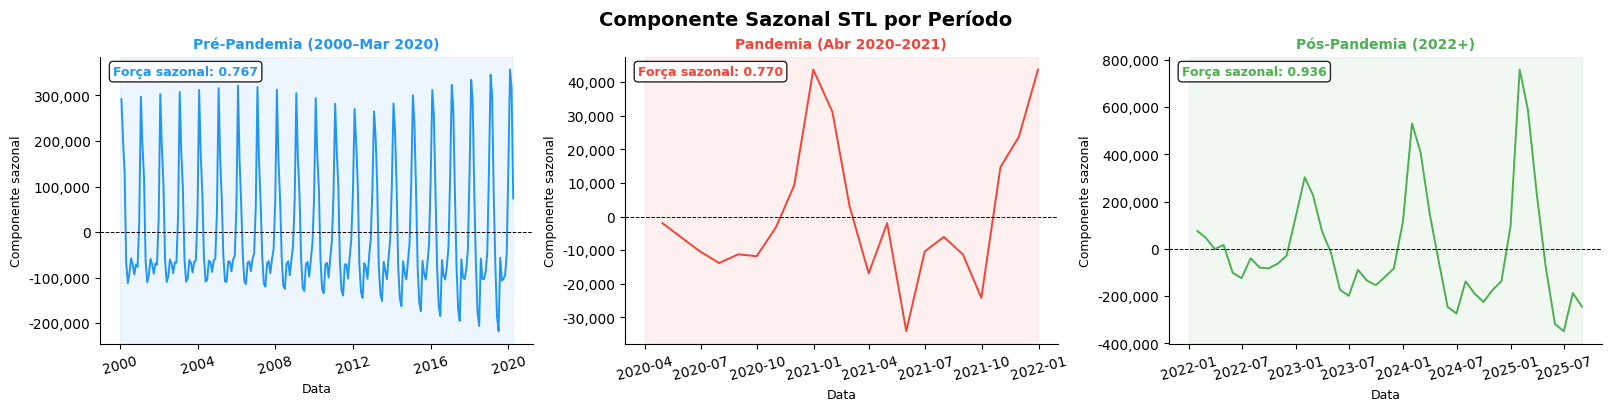

                                 Força Sazonal
Período                                       
Período Completo (2000–presente)        0.7159
Pré-Pandemia (2000–Mar 2020)            0.7674
Pandemia (Abr 2020–2021)                0.7700
Pós-Pandemia (2022+)                    0.9355


In [168]:
def stl_seasonal_strength(result):
    """max(0, 1 - Var(resid) / Var(seasonal + resid))"""
    var_resid = np.var(result.resid)
    var_seasonal_resid = np.var(result.seasonal + result.resid)
    return max(0.0, 1 - var_resid / var_seasonal_resid)


seasonal_periods = [
    (
        'Pré-Pandemia (2000–Mar 2020)',
        pd.Timestamp('2000-01-01'),
        COVID_START - pd.Timedelta(days=1),
    ),
    ('Pandemia (Abr 2020–2021)', COVID_START, COVID_END),
    ('Pós-Pandemia (2022+)', pd.Timestamp('2022-01-01'), monthly_df.index[-1]),
]

# ── fit STL for full period + each sub-period ─────────────────────────────────
post_2000 = monthly_df[monthly_df['period'] != 'Legado (< 2000)']

full_series = post_2000['arrival_count'].dropna()
full_result = STL(full_series, period=12, seasonal=13, robust=True).fit()
full_strength = stl_seasonal_strength(full_result)

period_stl = {}
for period, start, end in seasonal_periods:
    seg = monthly_df[(monthly_df.index >= start) & (monthly_df.index <= end)]
    series = seg['arrival_count'].dropna()
    # pandemic is too short for STL with seasonal=13; use seasonal=7
    s_window = 7 if len(series) < 36 else 13
    result = STL(series, period=12, seasonal=s_window, robust=True).fit()
    period_stl[period] = dict(result=result, strength=stl_seasonal_strength(result))

# ── 1×3 seasonal component plot ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
fig.suptitle('Componente Sazonal STL por Período', fontsize=14, fontweight='bold')

for ax, (period, start, end) in zip(axes, seasonal_periods):
    color = period_colors[period]
    res = period_stl[period]['result']
    fs = period_stl[period]['strength']

    ax.plot(res.seasonal.index, res.seasonal.values, color=color, linewidth=1.4)
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax.axvspan(start, end, alpha=0.08, color=color)

    ax.annotate(
        f'Força sazonal: {fs:.3f}',
        xy=(0.03, 0.97),
        xycoords='axes fraction',
        va='top',
        fontsize=9,
        color=color,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85),
    )
    ax.set_title(period, fontsize=10, fontweight='bold', color=color)
    ax.set_xlabel('Data', fontsize=9)
    ax.set_ylabel('Componente sazonal', fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.tick_params(axis='x', rotation=15)
    sns.despine(ax=ax)

plt.show()

# ── summary table ─────────────────────────────────────────────────────────────
summary_seasonal = pd.DataFrame(
    [('Período Completo (2000–presente)', f'{full_strength:.4f}')]
    + [(p, f'{period_stl[p]["strength"]:.4f}') for p, _, _ in seasonal_periods],
    columns=['Período', 'Força Sazonal'],
).set_index('Período')

print(summary_seasonal.to_string())

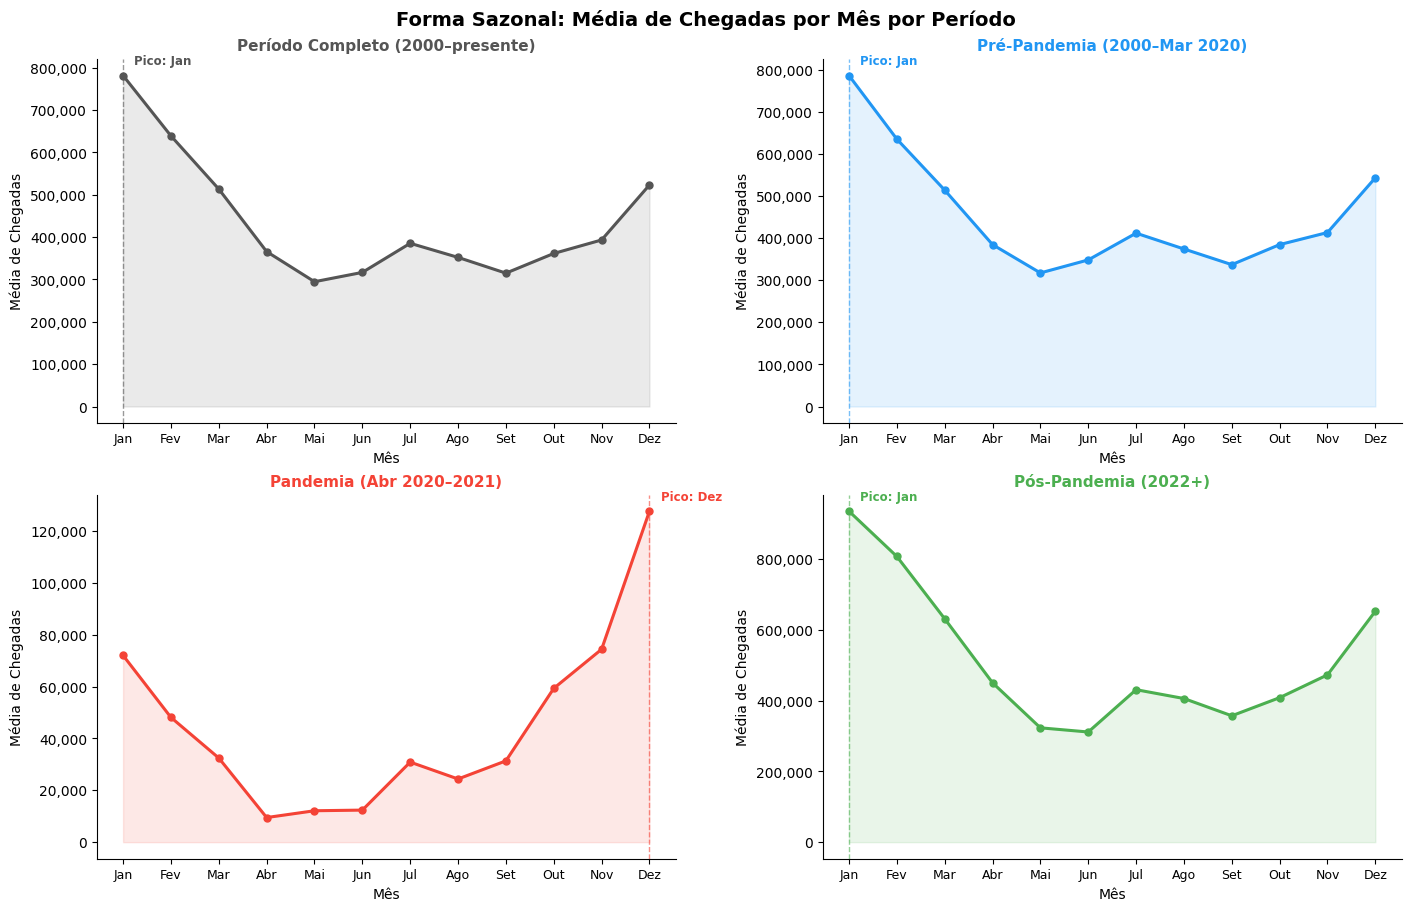

In [169]:
month_labels = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

shape_panels = [
    (
        'Período Completo (2000–presente)',
        monthly_df[monthly_df['period'] != 'Legado (< 2000)'],
        '#555555',
    ),
    (
        'Pré-Pandemia (2000–Mar 2020)',
        monthly_df[monthly_df['period'] == 'Pré-Pandemia (2000–Mar 2020)'],
        period_colors['Pré-Pandemia (2000–Mar 2020)'],
    ),
    (
        'Pandemia (Abr 2020–2021)',
        monthly_df[monthly_df['period'] == 'Pandemia (Abr 2020–2021)'],
        period_colors['Pandemia (Abr 2020–2021)'],
    ),
    (
        'Pós-Pandemia (2022+)',
        monthly_df[monthly_df['period'] == 'Pós-Pandemia (2022+)'],
        period_colors['Pós-Pandemia (2022+)'],
    ),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
fig.suptitle(
    'Forma Sazonal: Média de Chegadas por Mês por Período', fontsize=14, fontweight='bold'
)

for ax, (label, segment, color) in zip(axes.flat, shape_panels):
    monthly_means = (
        segment['arrival_count']
        .groupby(segment.index.month)
        .mean()
        .reindex(range(1, 13))
    )

    ax.plot(
        range(1, 13),
        monthly_means.values,
        color=color,
        linewidth=2.2,
        marker='o',
        markersize=5,
    )
    ax.fill_between(range(1, 13), monthly_means.values, alpha=0.12, color=color)

    peak_month = monthly_means.idxmax()
    ax.axvline(peak_month, color=color, linewidth=1, linestyle='--', alpha=0.6)
    ax.annotate(
        f'Pico: {month_labels[peak_month - 1]}',
        xy=(peak_month, monthly_means[peak_month]),
        xytext=(8, 8),
        textcoords='offset points',
        fontsize=8.5,
        color=color,
        fontweight='bold',
    )

    ax.set_title(label, fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel('Mês', fontsize=10)
    ax.set_ylabel('Média de Chegadas', fontsize=10)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels, fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    sns.despine(ax=ax)

plt.show()

##### Teste Estatístico de Sazonalidade

`check_seasonality` (Joseph & Tackes, *Modern Time Series Forecasting with Python* 2E,
`src/transforms/stationary_utils.py`, adaptado de `darts`) identifica máximos locais da FAC e aceita um lag candidato *m*
quando sua autocorrelação excede uma faixa de confiança baseada na fórmula de Bartlett. É executado em dois modos:

- **Inferido**: o primeiro pico significativo da FAC, buscado até `max_lag`.
- **Testado em m = 12**: verifica se o lag 12 é um máximo local da FAC e estatisticamente significativo.

Uma tendência forte domina a FAC e pode ocultar os picos sazonais; portanto, o teste também é
repetido após a remoção da tendência linear com `DetrendingTransformer` (mesma fonte,
`src/transforms/target_transformations.py`), que é a ordem adotada pelo `AutoStationaryTransformer`.


In [170]:
# Helpers `check_seasonality` / `DetrendingTransformer` from Joseph & Tackes,
# "Modern Time Series Forecasting with Python" 2E — src/transforms/


def seasonality_row(series, variant):
    n = len(series)
    inferred = check_seasonality(
        series, max_lag=min(36, n - 1), confidence=0.05, verbose=False
    )
    at_12 = (
        check_seasonality(
            series,
            max_lag=min(36, n - 1),
            seasonal_period=SEASONAL_PERIOD,
            confidence=0.05,
            verbose=False,
        )
        if n - 1 > SEASONAL_PERIOD
        else None
    )
    return {
        'Variant': variant,
        'n': n,
        'Inferred seasonal': '✓' if inferred.seasonal else '✗',
        'Inferred period': int(inferred.seasonal_periods) if inferred.seasonal else '—',
        'Seasonal at m=12': '—' if at_12 is None else ('✓' if at_12.seasonal else '✗'),
    }


seasonality_rows = []
for label, series in period_series.items():
    detrended = DetrendingTransformer(degree=1).fit_transform(series, freq=FREQ)
    for variant, s in [('Raw', series), ('Detrended (linear)', detrended)]:
        seasonality_rows.append({'Period': label, **seasonality_row(s, variant)})

seasonality_tests = pd.DataFrame(seasonality_rows).set_index(['Period', 'Variant'])

print('=' * 90)
print('SEASONALITY TEST — ACF local maxima + Bartlett band (check_seasonality)')
print('=' * 90)
print(seasonality_tests.to_string())

SEASONALITY TEST — ACF local maxima + Bartlett band (check_seasonality)
                                                       n Inferred seasonal  Inferred period Seasonal at m=12
Period                           Variant                                                                    
Período Completo (2000–presente) Raw                 308                 ✓                6                ✓
                                 Detrended (linear)  308                 ✓                6                ✓
Pré-Pandemia (2000–Mar 2020)     Raw                 243                 ✓               12                ✓
                                 Detrended (linear)  243                 ✓               12                ✓
Pandemia (Abr 2020–2021)         Raw                  21                 ✓               11                ✗
                                 Detrended (linear)   21                 ✓               12                ✓
Pós-Pandemia (2022+)             Raw                  44

#### Estacionariedade


STATIONARITY TEST RESULTS — ADF + KPSS
ADF  H0: unit root (non-stationary) → reject (p < 0.05) = stationary
KPSS H0: stationary                 → reject (p < 0.05) = non-stationary
                     Período    Transformação  ADF p ADF stationary  KPSS p KPSS stationary Veredito conjunto
    Completo (2000–presente)            Bruta 0.1356              ✗  0.1000               ✓           Ambíguo
    Completo (2000–presente)          Diff(1) 0.0000              ✓  0.1000               ✓      Estacionário
    Completo (2000–presente)         Diff(12) 0.0051              ✓  0.1000               ✓      Estacionário
    Completo (2000–presente) Diff(1)+Diff(12) 0.0000              ✓  0.1000               ✓      Estacionário
Pré-Pandemia (2000–Mar 2020)            Bruta 0.6776              ✗  0.0100               ✗  Não estacionário
Pré-Pandemia (2000–Mar 2020)          Diff(1) 0.0000              ✓  0.1000               ✓      Estacionário
Pré-Pandemia (2000–Mar 2020)         Diff(12) 0.0

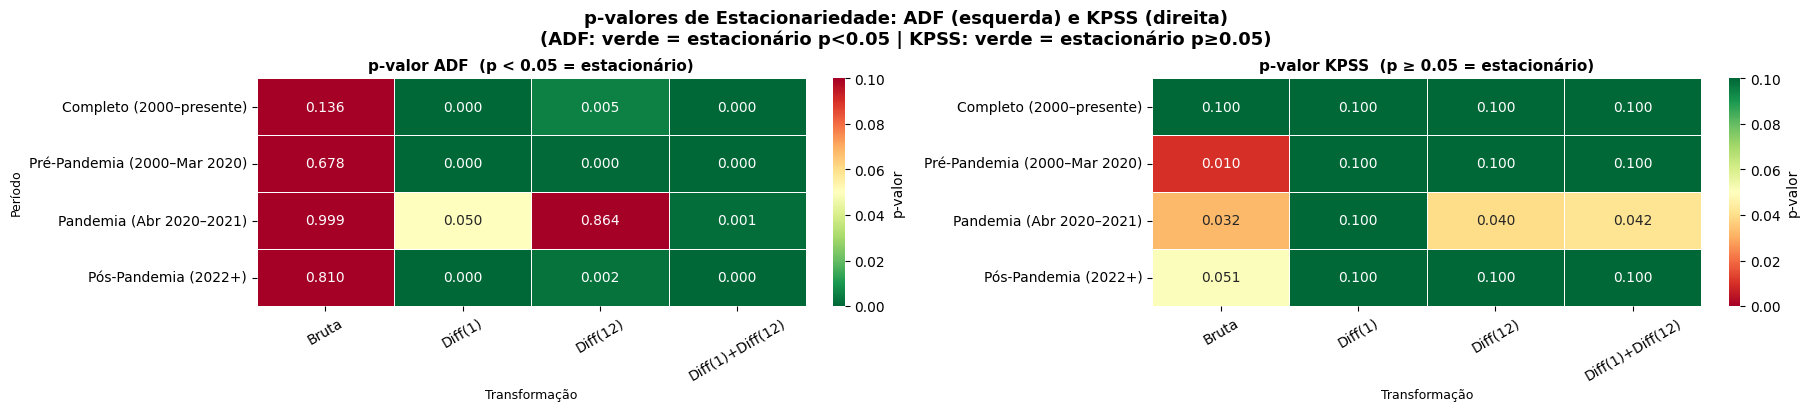

In [171]:
def run_adf(series, label):
    """ADF: H0 = unit root (non-stationary). p < 0.05 → stationary."""
    result = adfuller(series.dropna(), autolag='AIC')
    return {
        'label': label,
        'stat': result[0],
        'p': result[1],
        'lags': result[2],
        'stationary_adf': result[1] < 0.05,
    }


def run_kpss(series, label):
    """KPSS: H0 = stationary. p < 0.05 → non-stationary."""
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        stat, p, lags, _ = kpss(series.dropna(), regression='c', nlags='auto')
    return {
        'label': label,
        'stat': stat,
        'p': p,
        'lags': lags,
        'stationary_kpss': p >= 0.05,
    }


def joint_verdict(adf_row, kpss_row):
    """
    ADF stationary + KPSS stationary → Stationary
    ADF non-stationary + KPSS non-stationary → Non-stationary
    Disagreement → ambiguous (difference and retest)
    """
    a, k = adf_row['stationary_adf'], kpss_row['stationary_kpss']
    if a and k:
        return 'Estacionário'
    if not a and not k:
        return 'Não estacionário'
    return 'Ambíguo'


def test_series(series, label):
    a = run_adf(series, label)
    k = run_kpss(series, label)
    return a, k, joint_verdict(a, k)


def stationarity_grid(periods, transformations):
    """Run ADF + KPSS for every (period, transformation) pair."""
    rows = []
    for period_label, raw_series in periods:
        for trans_label, fn in transformations:
            try:
                s = fn(raw_series, period_label).dropna()
                if len(s) < 8:
                    continue
                adf_r, kpss_r, verdict = test_series(
                    s, f'{period_label} | {trans_label}'
                )
                rows.append({
                    'Período': period_label,
                    'Transformação': trans_label,
                    'ADF stat': round(adf_r['stat'], 4),
                    'ADF p': round(adf_r['p'], 4),
                    'ADF lags': adf_r['lags'],
                    'ADF stationary': '✓' if adf_r['stationary_adf'] else '✗',
                    'KPSS stat': round(kpss_r['stat'], 4),
                    'KPSS p': round(kpss_r['p'], 4),
                    'KPSS stationary': '✓' if kpss_r['stationary_kpss'] else '✗',
                    'Veredito conjunto': verdict,
                })
            except Exception as e:
                rows.append({
                    'Período': period_label,
                    'Transformação': trans_label,
                    'ADF stat': None,
                    'ADF p': None,
                    'ADF lags': None,
                    'ADF stationary': 'ERR',
                    'KPSS stat': None,
                    'KPSS p': None,
                    'KPSS stationary': 'ERR',
                    'Veredito conjunto': str(e),
                })
    return pd.DataFrame(rows)


def plot_stationarity_heatmaps(stat_df, trans_order, period_label_order, title):
    pivot_adf = stat_df.pivot_table(
        index='Período', columns='Transformação', values='ADF p', aggfunc='first'
    ).reindex(index=period_label_order, columns=trans_order)
    pivot_kpss = stat_df.pivot_table(
        index='Período', columns='Transformação', values='KPSS p', aggfunc='first'
    ).reindex(index=period_label_order, columns=trans_order)

    fig, axes = plt.subplots(1, 2, figsize=(18, 4), constrained_layout=True)
    fig.suptitle(
        f'{title}\n(ADF: verde = estacionário p<0.05 | KPSS: verde = estacionário p≥0.05)',
        fontsize=13,
        fontweight='bold',
    )

    # ADF heatmap: low p → stationary → green
    sns.heatmap(
        pivot_adf.astype(float),
        ax=axes[0],
        annot=True,
        fmt='.3f',
        cmap='RdYlGn_r',
        vmin=0,
        vmax=0.1,
        linewidths=0.4,
        cbar_kws={'label': 'p-valor'},
    )
    axes[0].set_title(
        'p-valor ADF  (p < 0.05 = estacionário)', fontsize=11, fontweight='bold'
    )

    # KPSS heatmap: high p → stationary → green
    sns.heatmap(
        pivot_kpss.astype(float),
        ax=axes[1],
        annot=True,
        fmt='.3f',
        cmap='RdYlGn',
        vmin=0,
        vmax=0.1,
        linewidths=0.4,
        cbar_kws={'label': 'p-valor'},
    )
    axes[1].set_title(
        'p-valor KPSS  (p ≥ 0.05 = estacionário)', fontsize=11, fontweight='bold'
    )
    axes[1].set_ylabel('')

    for ax in axes:
        ax.set_xlabel('Transformação', fontsize=9)
        ax.tick_params(axis='x', rotation=30)
        ax.tick_params(axis='y', rotation=0)
    axes[0].set_ylabel('Período', fontsize=9)

    plt.show()


# ── series variants to test ───────────────────────────────────────────────────

stationarity_periods = [
    (
        'Completo (2000–presente)',
        monthly_df[monthly_df['period'] != 'Legado (< 2000)']['arrival_count'],
    ),
    (
        'Pré-Pandemia (2000–Mar 2020)',
        monthly_df[monthly_df['period'] == 'Pré-Pandemia (2000–Mar 2020)'][
            'arrival_count'
        ],
    ),
    (
        'Pandemia (Abr 2020–2021)',
        monthly_df[monthly_df['period'] == 'Pandemia (Abr 2020–2021)']['arrival_count'],
    ),
    (
        'Pós-Pandemia (2022+)',
        monthly_df[monthly_df['period'] == 'Pós-Pandemia (2022+)']['arrival_count'],
    ),
]
period_label_order = [p for p, _ in stationarity_periods]

transformations = [
    ('Bruta', lambda s, _: s),
    ('Diff(1)', lambda s, _: s.diff(1)),
    ('Diff(12)', lambda s, _: s.diff(12)),
    ('Diff(1)+Diff(12)', lambda s, _: s.diff(1).diff(12)),
]
trans_order = [t for t, _ in transformations]

# ── run all tests ─────────────────────────────────────────────────────────────

stat_df = stationarity_grid(stationarity_periods, transformations)

# ── display full table ────────────────────────────────────────────────────────

display_cols = [
    'Período',
    'Transformação',
    'ADF p',
    'ADF stationary',
    'KPSS p',
    'KPSS stationary',
    'Veredito conjunto',
]

print('=' * 100)
print('STATIONARITY TEST RESULTS — ADF + KPSS')
print('ADF  H0: unit root (non-stationary) → reject (p < 0.05) = stationary')
print('KPSS H0: stationary                 → reject (p < 0.05) = non-stationary')
print('=' * 100)
print(stat_df[display_cols].to_string(index=False))

# ── SARIMA order recommendation ───────────────────────────────────────────────

print()
print('=' * 70)
print('SARIMA DIFFERENCING RECOMMENDATION')
print('=' * 70)

for period_label, _ in stationarity_periods:
    sub = stat_df[stat_df['Período'] == period_label]

    def verdict_for(trans, sub=sub):
        row = sub[sub['Transformação'] == trans]
        return row['Veredito conjunto'].values[0] if len(row) else 'N/A'

    raw_v = verdict_for('Bruta')
    d1_v = verdict_for('Diff(1)')
    d12_v = verdict_for('Diff(12)')
    d1d12_v = verdict_for('Diff(1)+Diff(12)')

    # infer d
    if raw_v == 'Estacionário':
        d = 0
    elif d1_v == 'Estacionário':
        d = 1
    else:
        d = 2

    # infer D (seasonal differencing, period=12)
    D = 0 if raw_v == 'Estacionário' else 1

    print(f'\n{period_label}')
    print(f'  Raw              → {raw_v}')
    print(f'  Diff(1)          → {d1_v}')
    print(f'  Diff(12)         → {d12_v}')
    print(f'  Diff(1)+Diff(12) → {d1d12_v}')
    print(f'  Suggested: d={d}, D={D}, s=12  →  SARIMA(p, {d}, q)(P, {D}, Q)[12]')

# ── visual: heatmap of ADF / KPSS p-values ───────────────────────────────────

plot_stationarity_heatmaps(
    stat_df,
    trans_order,
    period_label_order,
    'p-valores de Estacionariedade: ADF (esquerda) e KPSS (direita)',
)

#### Autocorrelação


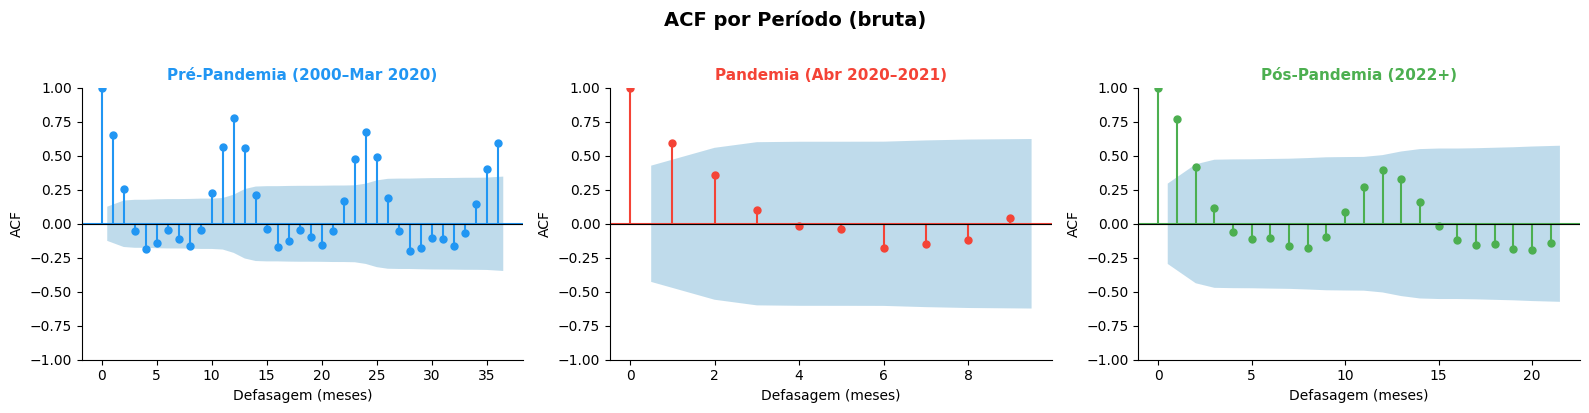

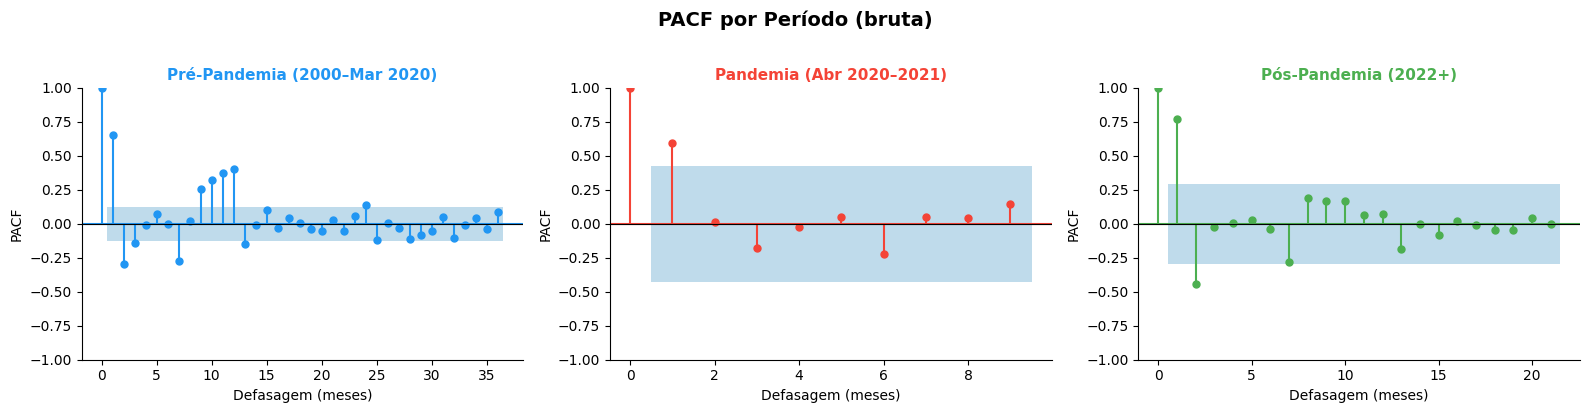

In [172]:
acf_periods = [
    'Pré-Pandemia (2000–Mar 2020)',
    'Pandemia (Abr 2020–2021)',
    'Pós-Pandemia (2022+)',
]

for plot_fn, fn_label in [(plot_acf, 'ACF'), (plot_pacf, 'PACF')]:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(
        f'{fn_label} por Período (bruta)',
        fontsize=14,
        fontweight='bold',
        y=1.02,
    )

    for ax, period in zip(axes, acf_periods):
        series = monthly_df.loc[monthly_df['period'] == period, 'arrival_count']
        lags = min(36, len(series) // 2 - 1)
        color = period_colors[period]

        plot_fn(series, lags=lags, ax=ax, color=color, vlines_kwargs={'colors': color})

        ax.set_title(period, fontsize=11, fontweight='bold', color=color)
        ax.set_xlabel('Defasagem (meses)', fontsize=10)
        ax.set_ylabel(fn_label, fontsize=10)
        ax.axhline(0, color='black', linewidth=0.8)
        sns.despine(ax=ax)

    plt.tight_layout()
    plt.show()


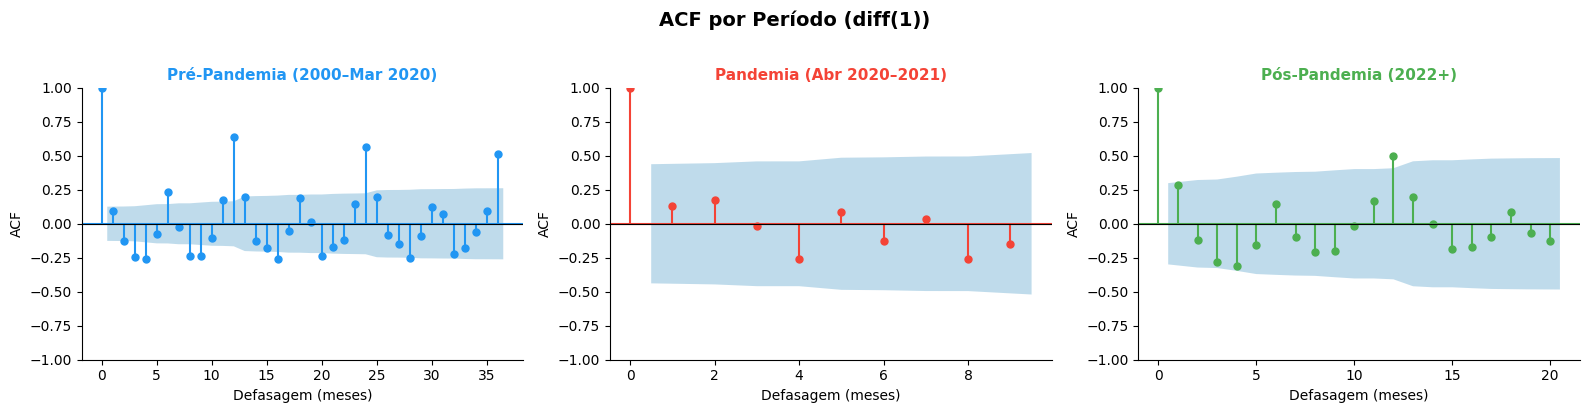

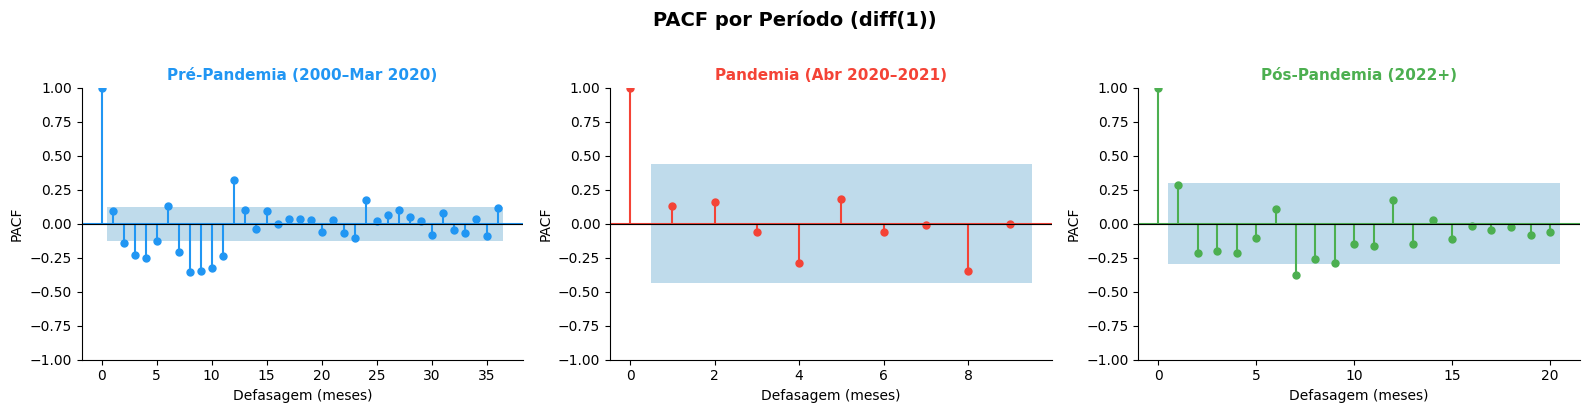

In [173]:
for plot_fn, fn_label in [(plot_acf, 'ACF'), (plot_pacf, 'PACF')]:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(
        f'{fn_label} por Período (diff(1))',
        fontsize=14,
        fontweight='bold',
        y=1.02,
    )

    for ax, period in zip(axes, acf_periods):
        series = (
            monthly_df
            .loc[monthly_df['period'] == period, 'arrival_count']
            .diff(1)
            .dropna()
        )
        lags = min(36, len(series) // 2 - 1)
        color = period_colors[period]

        plot_fn(series, lags=lags, ax=ax, color=color, vlines_kwargs={'colors': color})

        ax.set_title(period, fontsize=11, fontweight='bold', color=color)
        ax.set_xlabel('Defasagem (meses)', fontsize=10)
        ax.set_ylabel(fn_label, fontsize=10)
        ax.axhline(0, color='black', linewidth=0.8)
        sns.despine(ax=ax)

    plt.tight_layout()
    plt.show()

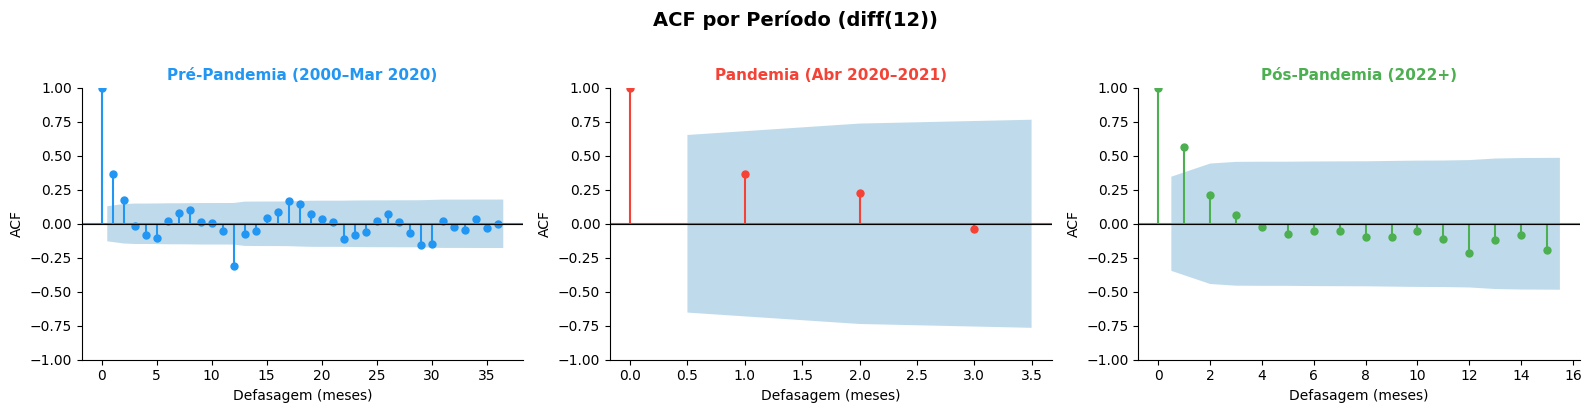

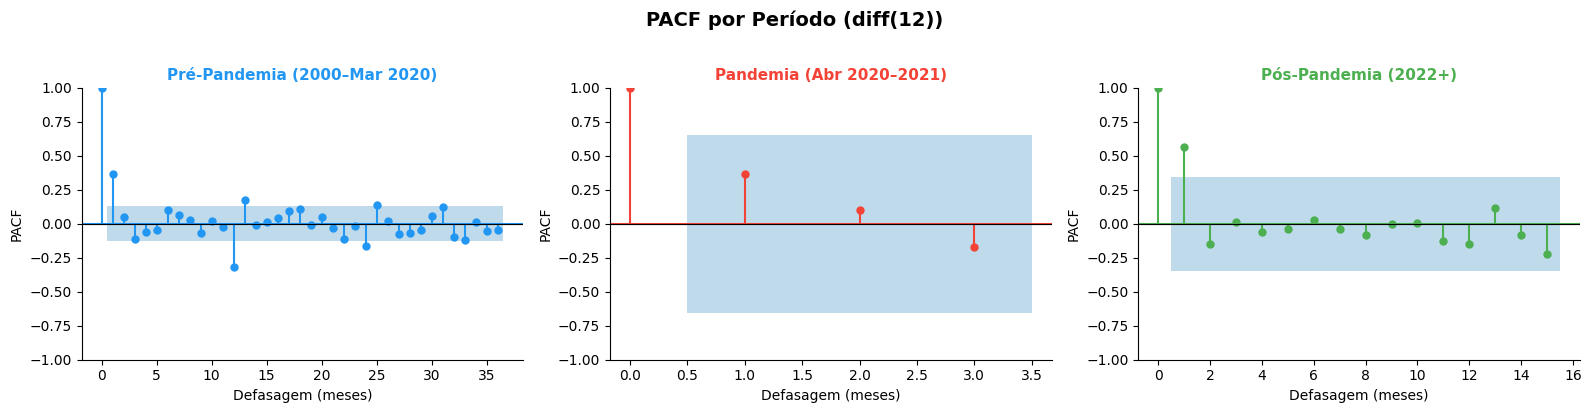

In [174]:
for plot_fn, fn_label in [(plot_acf, 'ACF'), (plot_pacf, 'PACF')]:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(
        f'{fn_label} por Período (diff(12))',
        fontsize=14,
        fontweight='bold',
        y=1.02,
    )

    for ax, period in zip(axes, acf_periods):
        series = (
            monthly_df
            .loc[monthly_df['period'] == period, 'arrival_count']
            .diff(12)
            .dropna()
        )
        lags = min(36, len(series) // 2 - 1)
        color = period_colors[period]

        plot_fn(series, lags=lags, ax=ax, color=color, vlines_kwargs={'colors': color})

        ax.set_title(period, fontsize=11, fontweight='bold', color=color)
        ax.set_xlabel('Defasagem (meses)', fontsize=10)
        ax.set_ylabel(fn_label, fontsize=10)
        ax.axhline(0, color='black', linewidth=0.8)
        sns.despine(ax=ax)

    plt.tight_layout()
    plt.show()

#### Heterocedasticidade

Uma série temporal é heterocedástica quando sua variância se altera ao longo do tempo. Em chegadas de turistas,
isso normalmente se manifesta como uma amplitude sazonal que cresce proporcionalmente ao nível médio da série.
É exatamente isso que a verificação de média–desvio padrão na seção *Tendência* sugere. Isso é crucial porque
modelos da família ARIMA assumem variância de erro constante. Uma variância dependente do nível também torna
os intervalos de previsão excessivamente estreitos nos picos e excessivamente largos nos vales.

Duas verificações complementares:

1. **Visual**: média móvel de 12 meses, desvio padrão móvel e coeficiente de variação móvel (std / média).
   Um CV constante acompanhado de um desvio padrão crescente aponta para comportamento multiplicativo.
2. **Teste de White** via `check_heteroscedastisticity` (Joseph & Tackes, *Modern Time Series
   Forecasting with Python* 2E, `src/transforms/stationary_utils.py`). A função ajusta uma tendência linear
   e executa o teste de White sobre os resíduos (H0: homocedasticidade). O teste é aplicado à série bruta e
   à série após remoção de tendência linear e de sazonalidade por médias do período
   (`DetrendingTransformer` → `DeseasonalizingTransformer`, mesma fonte). Assim, o ciclo sazonal não é
   confundido com variância variável.


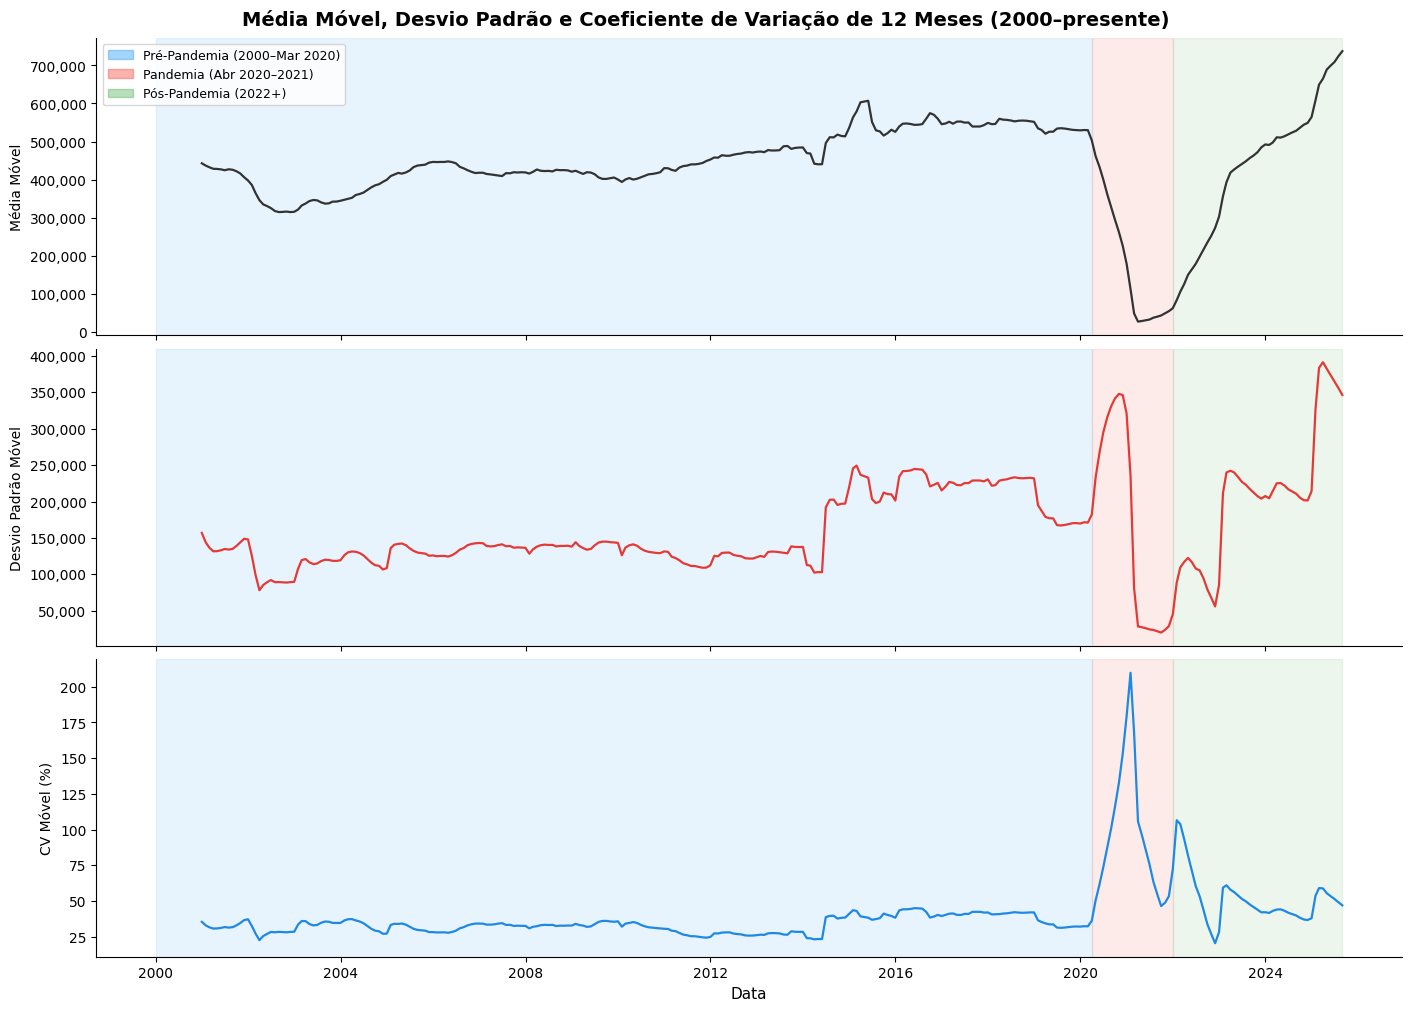

In [175]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True, constrained_layout=True)
fig.suptitle(
    'Média Móvel, Desvio Padrão e Coeficiente de Variação de 12 Meses (2000–presente)',
    fontsize=14,
    fontweight='bold',
)

full_series = period_series['Período Completo (2000–presente)']
rolling_mean = full_series.rolling(12).mean()
rolling_std = full_series.rolling(12).std()
rolling_cv = rolling_std / rolling_mean * 100

for ax, values, label, color in [
    (axes[0], rolling_mean, 'Média Móvel', '#333333'),
    (axes[1], rolling_std, 'Desvio Padrão Móvel', '#e53935'),
    (axes[2], rolling_cv, 'CV Móvel (%)', '#1e88e5'),
]:
    ax.plot(values.index, values, color=color, linewidth=1.6)
    for period, start, end in trend_periods:
        ax.axvspan(start, end, alpha=0.1, color=period_colors[period])
    ax.set_ylabel(label, fontsize=10)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    sns.despine(ax=ax)

axes[0].legend(
    handles=[
        mpatches.Patch(color=period_colors[p], alpha=0.4, label=p)
        for p, _, _ in trend_periods
    ],
    fontsize=9,
    frameon=True,
    loc='upper left',
)
axes[-1].set_xlabel('Data', fontsize=11)
plt.show()

In [176]:
# Helpers `check_heteroscedastisticity`, `DetrendingTransformer` and
# `DeseasonalizingTransformer` from Joseph & Tackes, "Modern Time Series Forecasting
# with Python" 2E — src/transforms/


def detrend_deseasonalize(series):
    """Linear detrend + period-average deseasonalize (AutoStationary order)."""
    detrended = DetrendingTransformer(degree=1).fit_transform(series, freq=FREQ)
    if len(detrended) <= 2 * SEASONAL_PERIOD:
        return detrended
    return DeseasonalizingTransformer(
        seasonal_period=SEASONAL_PERIOD, seasonality_extraction='period_averages'
    ).fit_transform(detrended, freq=FREQ)


def white_row(series, variant):
    res = check_heteroscedastisticity(series, confidence=0.05)
    return {
        'Variant': variant,
        'White LM stat': round(res.lm_statistic, 3),
        'White LM p': round(res.lm_p_value, 4),
        'Heteroscedastic': '✓' if res.heteroscedastic else '✗',
    }


hetero_rows = []
for label, series in period_series.items():
    hetero_rows.append({'Period': label, **white_row(series, 'Raw')})
    hetero_rows.append({
        'Period': label,
        **white_row(detrend_deseasonalize(series), 'Detrended + deseasonalized'),
    })

hetero_tests = pd.DataFrame(hetero_rows).set_index(['Period', 'Variant'])

print('=' * 90)
print('WHITE TEST — H0: homoscedastic → reject (LM and F p < 0.05) = heteroscedastic')
print('=' * 90)
print(hetero_tests.to_string())

WHITE TEST — H0: homoscedastic → reject (LM and F p < 0.05) = heteroscedastic
                                                             White LM stat  White LM p Heteroscedastic
Period                           Variant                                                              
Período Completo (2000–presente) Raw                                35.552      0.0000               ✓
                                 Detrended + deseasonalized         39.978      0.0000               ✓
Pré-Pandemia (2000–Mar 2020)     Raw                                10.891      0.0043               ✓
                                 Detrended + deseasonalized          3.386      0.1840               ✗
Pandemia (Abr 2020–2021)         Raw                                 5.731      0.0570               ✗
                                 Detrended + deseasonalized          5.731      0.0570               ✗
Pós-Pandemia (2022+)             Raw                                 3.452      0.1780            

#### Transformação Box-Cox (Método de Guerrero para λ)

Em vez de fixar arbitrariamente λ = 0 (log), a transformação de potência de Box-Cox

$$
y^{(\lambda)} =
\begin{cases}
\dfrac{y^{\lambda} - 1}{\lambda}, & \lambda \neq 0 \\
\log y, & \lambda = 0
\end{cases}
$$

é ajustada com λ escolhido pelo **método de Guerrero** (Guerrero, 1993, *Journal of Forecasting* 12, 37–48).
A série é dividida em blocos sazonais consecutivos (m = 12, isto é, anos civis). Guerrero escolhe o λ que torna
$\sigma_h / \mu_h^{1-\lambda}$ o mais constante possível entre os blocos, medido pelo seu coeficiente de variação.
Em outros termos, λ é a potência que melhor elimina a dependência entre o nível e a dispersão.

A transformação utiliza `BoxCoxTransformer(seasonal_period=12, optimization='guerrero', bounds=(-1, 2))`
de Joseph & Tackes, *Modern Time Series Forecasting with Python* 2E (`src/transforms/target_transformations.py`).
O otimizador de Guerrero foi adaptado pelos autores a partir do `sktime`.

Interpretação de λ: **≈ 1** nenhuma transformação necessária · **≈ 0.5** raiz quadrada · **≈ 0** logaritmo ·
**< 0** potência inversa (mais forte que log).


                                    n  Blocos de Guerrero (anos)  λ (Guerrero)             Interpretação
Período                                                                                                 
Período Completo (2000–presente)  308                         25        0.2135             ≈ log (λ ≈ 0)
Pré-Pandemia (2000–Mar 2020)      243                         20       -0.4306  potência inversa (λ < 0)
Pandemia (Abr 2020–2021)           21                          1        2.0000         ≈ nenhuma (λ ≈ 1)
Pós-Pandemia (2022+)               44                          3       -0.0444             ≈ log (λ ≈ 0)


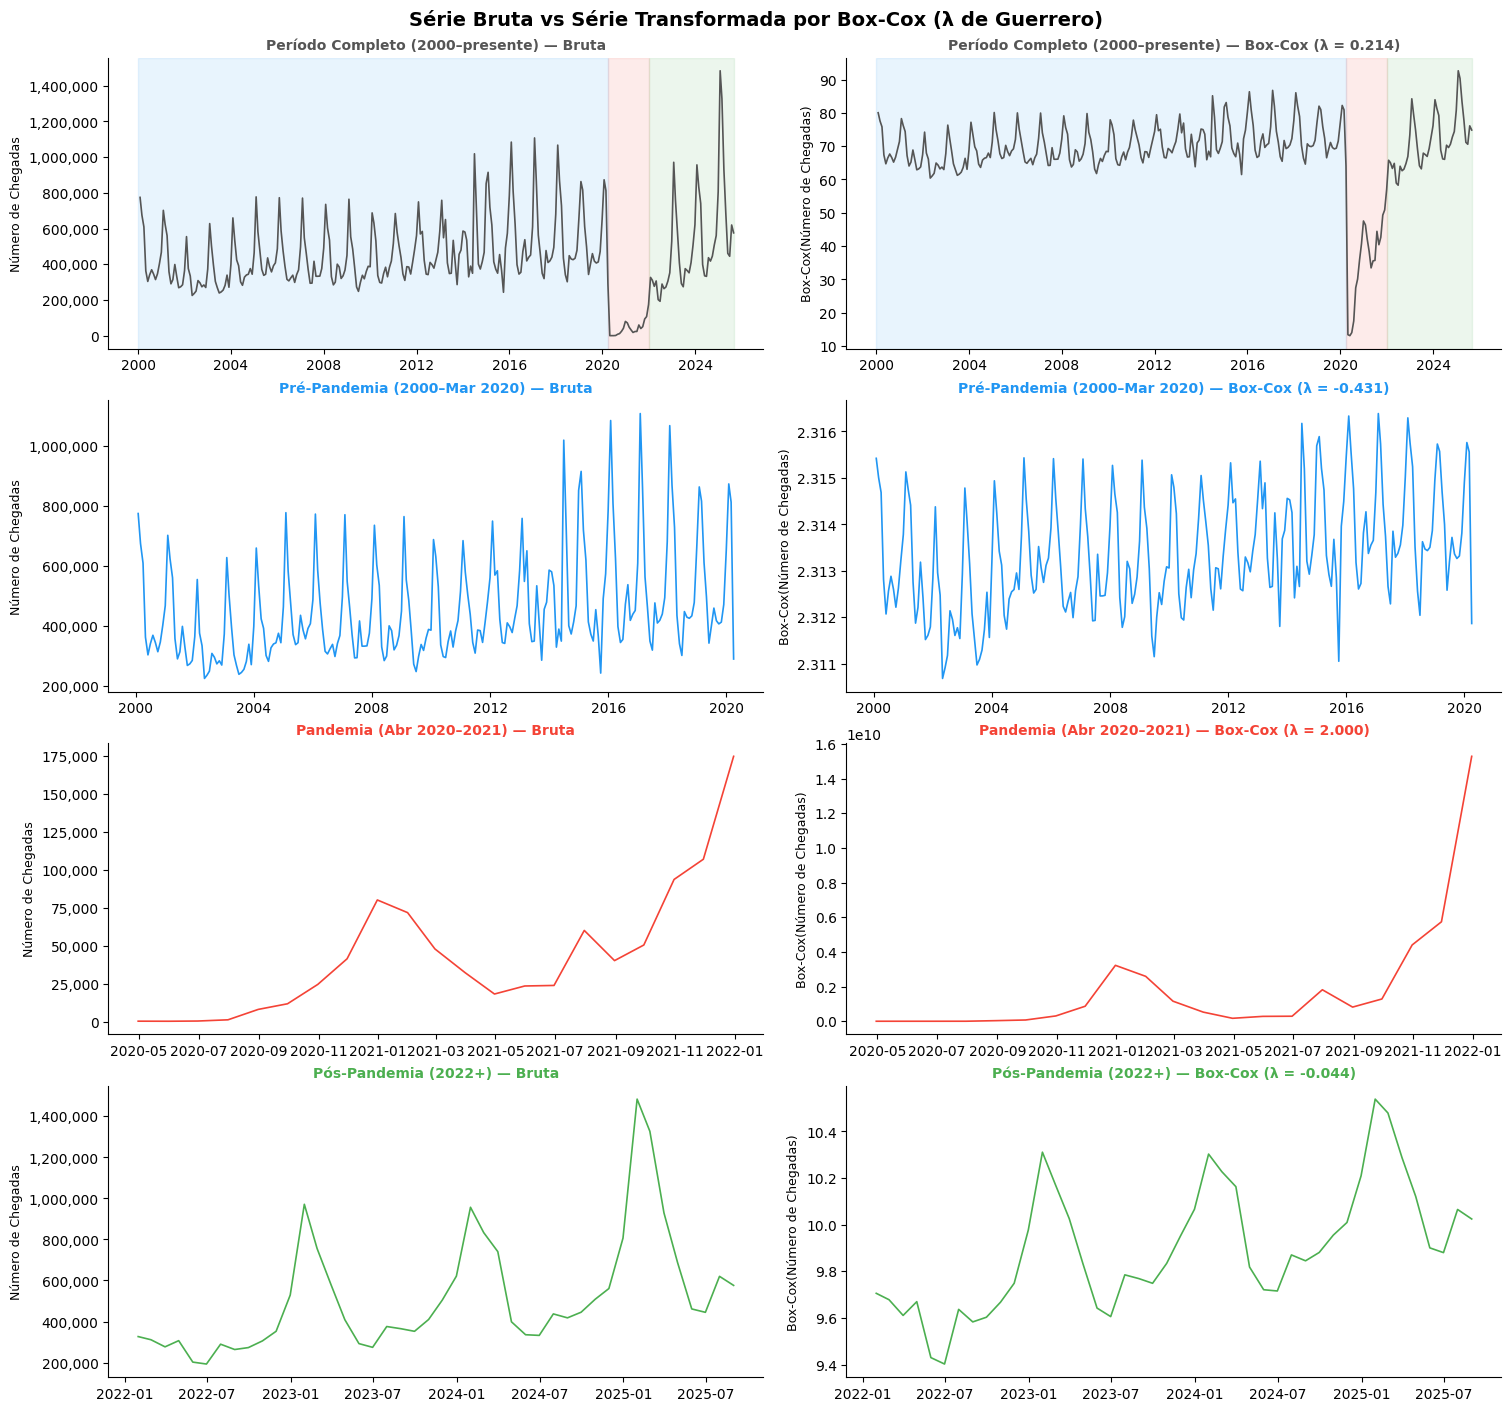

In [177]:
# Helper `BoxCoxTransformer` (Guerrero λ) from Joseph & Tackes, "Modern Time Series
# Forecasting with Python" 2E — src/transforms/target_transformations.py


def interpret_lambda(lmbda):
    if lmbda > 0.75:
        return '≈ nenhuma (λ ≈ 1)'
    if lmbda > 0.25:
        return '≈ raiz quadrada (λ ≈ 0.5)'
    if lmbda > -0.25:
        return '≈ log (λ ≈ 0)'
    return 'potência inversa (λ < 0)'


boxcox_fitted = {}
boxcox_series = {}
lambda_rows = []
for label, series in period_series.items():
    bc = BoxCoxTransformer(
        seasonal_period=SEASONAL_PERIOD, optimization='guerrero', bounds=(-1, 2)
    )
    bc.fit(series)
    boxcox_fitted[label] = bc
    boxcox_series[label] = bc.transform(series)
    lambda_rows.append({
        'Período': label,
        'n': len(series),
        'Blocos de Guerrero (anos)': len(series) // SEASONAL_PERIOD,
        'λ (Guerrero)': round(bc.boxcox_lambda, 4),
        'Interpretação': interpret_lambda(bc.boxcox_lambda),
    })

boxcox_lambdas = pd.DataFrame(lambda_rows).set_index('Período')
print(boxcox_lambdas.to_string())

# ── raw vs Box-Cox per period ────────────────────────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(15, 14), constrained_layout=True)
fig.suptitle(
    'Série Bruta vs Série Transformada por Box-Cox (λ de Guerrero)',
    fontsize=14,
    fontweight='bold',
)

for row, (label, series) in enumerate(period_series.items()):
    color = period_series_colors[label]
    lmbda = boxcox_fitted[label].boxcox_lambda

    axes[row, 0].plot(series.index, series, color=color, linewidth=1.2)
    axes[row, 0].set_title(
        f'{label} — Bruta', fontsize=10, fontweight='bold', color=color
    )
    axes[row, 0].set_ylabel('Número de Chegadas', fontsize=9)
    axes[row, 0].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{int(x):,}')
    )

    transformed = boxcox_series[label]
    axes[row, 1].plot(transformed.index, transformed, color=color, linewidth=1.2)
    axes[row, 1].set_title(
        f'{label} — Box-Cox (λ = {lmbda:.3f})',
        fontsize=10,
        fontweight='bold',
        color=color,
    )
    axes[row, 1].set_ylabel('Box-Cox(Número de Chegadas)', fontsize=9)

    if label == 'Período Completo (2000–presente)':
        for period, start, end in trend_periods:
            for ax in axes[row]:
                ax.axvspan(start, end, alpha=0.1, color=period_colors[period])

    for ax in axes[row]:
        sns.despine(ax=ax)

plt.show()

##### A Transformação Box-Cox Estabilizou a Variância?

Os mesmos diagnósticos são repetidos na escala de Box-Cox:

- a correlação anual média–desvio padrão da verificação aditiva/multiplicativa (calculada na série em nível), e
- o teste de White, executado em ambas as escalas **após** detrending e deseasonalizing (`detrend_deseasonalize` acima).

O período da pandemia possui apenas dois anos civis, portanto sua correlação média–desvio padrão é trivialmente ±1
e seu λ de Guerrero repousa em apenas dois blocos. Trate essa coluna apenas como indicativa.


In [178]:
def mean_std_corr(series):
    annual = series.resample('YE').agg(['mean', 'std']).dropna()
    return annual['mean'].corr(annual['std'])


variance_rows = []
for label, series in period_series.items():
    transformed = boxcox_series[label]
    raw_white = check_heteroscedastisticity(detrend_deseasonalize(series))
    bc_white = check_heteroscedastisticity(detrend_deseasonalize(transformed))
    variance_rows.append({
        'Period': label,
        'λ': round(boxcox_fitted[label].boxcox_lambda, 3),
        'Mean–std corr (raw)': round(mean_std_corr(series), 3),
        'Mean–std corr (Box-Cox)': round(mean_std_corr(transformed), 3),
        'White p (raw scale)': round(raw_white.lm_p_value, 4),
        'White p (Box-Cox scale)': round(bc_white.lm_p_value, 4),
        'Heteroscedastic (raw scale)': '✓' if raw_white.heteroscedastic else '✗',
        'Heteroscedastic (Box-Cox scale)': '✓' if bc_white.heteroscedastic else '✗',
    })

variance_comparison = pd.DataFrame(variance_rows).set_index('Period')
print(variance_comparison.T.to_string())

Period                          Período Completo (2000–presente) Pré-Pandemia (2000–Mar 2020) Pandemia (Abr 2020–2021) Pós-Pandemia (2022+)
λ                                                          0.214                       -0.431                      2.0               -0.044
Mean–std corr (raw)                                        0.597                        0.897                      1.0                0.992
Mean–std corr (Box-Cox)                                   -0.643                        0.358                      1.0                0.966
White p (raw scale)                                          0.0                        0.184                    0.057               0.0109
White p (Box-Cox scale)                                      0.0                       0.2633                   0.0253               0.0014
Heteroscedastic (raw scale)                                    ✓                            ✗                        ✗                    ✓
Heteroscedastic (Box

##### Estacionariedade na Escala Box-Cox

A grade de testes ADF + KPSS da seção *Estacionariedade* é reexecutada sobre a série transformada por Box-Cox.
Cada período utiliza seu próprio λ de Guerrero estimado. Isso substitui as variantes baseadas em log anteriormente testadas.


STATIONARITY TEST RESULTS — Box-Cox (Guerrero λ) variants
                     Período              Transformação  ADF p ADF stationary  KPSS p KPSS stationary Veredito conjunto
    Completo (2000–presente)                    Box-Cox 0.0255              ✓  0.1000               ✓      Estacionário
    Completo (2000–presente)          Box-Cox + Diff(1) 0.0000              ✓  0.1000               ✓      Estacionário
    Completo (2000–presente)         Box-Cox + Diff(12) 0.0031              ✓  0.1000               ✓      Estacionário
    Completo (2000–presente) Box-Cox + Diff(1)+Diff(12) 0.0000              ✓  0.1000               ✓      Estacionário
Pré-Pandemia (2000–Mar 2020)                    Box-Cox 0.5585              ✗  0.0100               ✗  Não estacionário
Pré-Pandemia (2000–Mar 2020)          Box-Cox + Diff(1) 0.0000              ✓  0.1000               ✓      Estacionário
Pré-Pandemia (2000–Mar 2020)         Box-Cox + Diff(12) 0.0022              ✓  0.1000               ✓ 

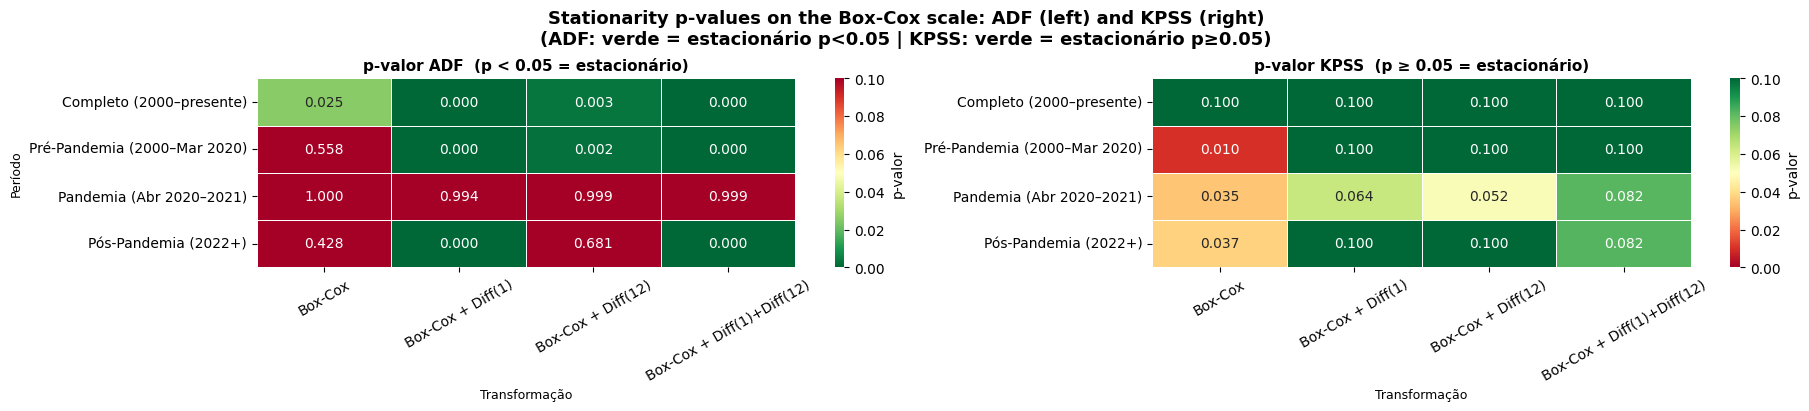

In [179]:
stationarity_label_map = dict(
    zip(period_label_order, period_series.keys())
)  # 'Full (2000–present)' → 'Período Completo (2000–presente)'


def boxcox_for(series, period_label):
    return boxcox_fitted[stationarity_label_map[period_label]].transform(series)


boxcox_transformations = [
    ('Box-Cox', boxcox_for),
    ('Box-Cox + Diff(1)', lambda s, p: boxcox_for(s, p).diff(1)),
    ('Box-Cox + Diff(12)', lambda s, p: boxcox_for(s, p).diff(12)),
    ('Box-Cox + Diff(1)+Diff(12)', lambda s, p: boxcox_for(s, p).diff(1).diff(12)),
]

stat_df_boxcox = stationarity_grid(stationarity_periods, boxcox_transformations)

print('=' * 100)
print('STATIONARITY TEST RESULTS — Box-Cox (Guerrero λ) variants')
print('=' * 100)
print(stat_df_boxcox[display_cols].to_string(index=False))

# side-by-side verdicts: raw vs Box-Cox
verdicts = pd.concat([stat_df, stat_df_boxcox]).pivot_table(
    index='Período', columns='Transformação', values='Veredito conjunto', aggfunc='first'
)
verdict_order = [
    'Bruta',
    'Box-Cox',
    'Diff(1)',
    'Box-Cox + Diff(1)',
    'Diff(12)',
    'Box-Cox + Diff(12)',
    'Diff(1)+Diff(12)',
    'Box-Cox + Diff(1)+Diff(12)',
]
print()
print('JOINT VERDICT — raw vs Box-Cox')
print(verdicts.reindex(index=period_label_order, columns=verdict_order).T.to_string())

plot_stationarity_heatmaps(
    stat_df_boxcox,
    [t for t, _ in boxcox_transformations],
    period_label_order,
    'Stationarity p-values on the Box-Cox scale: ADF (left) and KPSS (right)',
)

#### Transformação Automática de Estacionariedade (Abordagem AutoML)

Como etapa final, `AutoStationaryTransformer` (Joseph & Tackes, *Modern Time Series Forecasting with Python* 2E,
`src/transforms/target_transformations.py`) é empregado para que um pipeline baseado em regras selecione as transformações.
Durante o `fit`, ele executa os mesmos testes explorados acima, na seguinte ordem:

1. **Tendência**: `check_trend` (Mann-Kendall). Se tendência for detectada → `DetrendingTransformer(degree=1)`.
2. **Sazonalidade**: `check_seasonality` em m = 12. Se for sazonal e n > 2m → `DeseasonalizingTransformer` (médias de período).
3. **Heterocedasticidade**: `check_heteroscedastisticity` (White). Se heterocedástica → `AddMTransformer` quando
   necessário para tornar os valores positivos, seguido de `BoxCoxTransformer(optimization='guerrero')`.

A saída é então avaliada pelo par de testes ADF + KPSS da seção *Estacionariedade*. O pipeline ajustado também
deve ser capaz de reverter para a série original (erro de ida e volta - round-trip), uma vez que as previsões
precisarão ser mapeadas de volta para contagens de chegadas.

Note que o pipeline remove uma tendência linear **determinística**. Ele não diferencia a série, portanto uma tendência
estocástica (raiz unitária) ainda pode permanecer na saída.


In [180]:
# Helper `AutoStationaryTransformer` from Joseph & Tackes, "Modern Time Series
# Forecasting with Python" 2E — src/transforms/target_transformations.py

auto_transformers = {}
auto_outputs = {}
auto_rows = []
for label, series in period_series.items():
    # fresh dicts every fit: the transformer mutates its parameter dicts in place
    ast = AutoStationaryTransformer(
        confidence=0.05,
        seasonal_period=SEASONAL_PERIOD,
        trend_check_params={'mann_kendall': True},
        detrender_params={'degree': 1},
        deseasonalizer_params={},
        box_cox_params={'optimization': 'guerrero'},
    )
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        transformed = ast.fit_transform(series, freq=FREQ)
    auto_transformers[label] = ast
    auto_outputs[label] = transformed

    steps = [type(tr).__name__.replace('Transformer', '') for tr in ast._pipeline]
    box_cox = [tr for tr in ast._pipeline if isinstance(tr, BoxCoxTransformer)]
    roundtrip_error = (ast.inverse_transform(transformed) - series).abs().max()
    adf_r, kpss_r, verdict = test_series(transformed, label)

    trend_flag = '✓' if ast._trend_check['trend'] else '✗'
    hetero_flag = '✓' if ast._hetero_check['heteroscedastic'] else '✗'
    auto_rows.append({
        'Period': label,
        'Pipeline': ' → '.join(steps) if steps else '(none)',
        'Trend (MK p)': f'{trend_flag} ({ast._trend_check["p_value"]:.4f})',
        'Seasonal (m=12)': '✓' if ast._seasonality_check['seasonal'] else '✗',
        'Heteroscedastic (White p)': (
            f'{hetero_flag} ({ast._hetero_check["lm_p_value"]:.4f})'
        ),
        'Box-Cox λ': f'{box_cox[0].boxcox_lambda:.3f}' if box_cox else '—',
        'ADF p': round(adf_r['p'], 4),
        'KPSS p': round(kpss_r['p'], 4),
        'Joint verdict': verdict,
        'Inverse round-trip max |error|': f'{roundtrip_error:.2e}',
    })

auto_summary = pd.DataFrame(auto_rows).set_index('Period')

print('=' * 100)
print('AUTO STATIONARY TRANSFORMER — fitted pipelines and stationarity of the output')
print('=' * 100)
print(auto_summary.T.to_string())

AUTO STATIONARY TRANSFORMER — fitted pipelines and stationarity of the output
Period                                      Período Completo (2000–presente)  Pré-Pandemia (2000–Mar 2020) Pandemia (Abr 2020–2021)             Pós-Pandemia (2022+)
Pipeline                        Detrending → Deseasonalizing → AddM → BoxCox  Detrending → Deseasonalizing               Detrending  Deseasonalizing → AddM → BoxCox
Trend (MK p)                                                      ✓ (0.0084)                    ✓ (0.0000)               ✓ (0.0058)                       ✗ (0.1070)
Seasonal (m=12)                                                            ✓                             ✓                        ✓                                ✓
Heteroscedastic (White p)                                         ✓ (0.0000)                    ✗ (0.1840)               ✗ (0.0570)                       ✓ (0.0400)
Box-Cox λ                                                              0.989                     

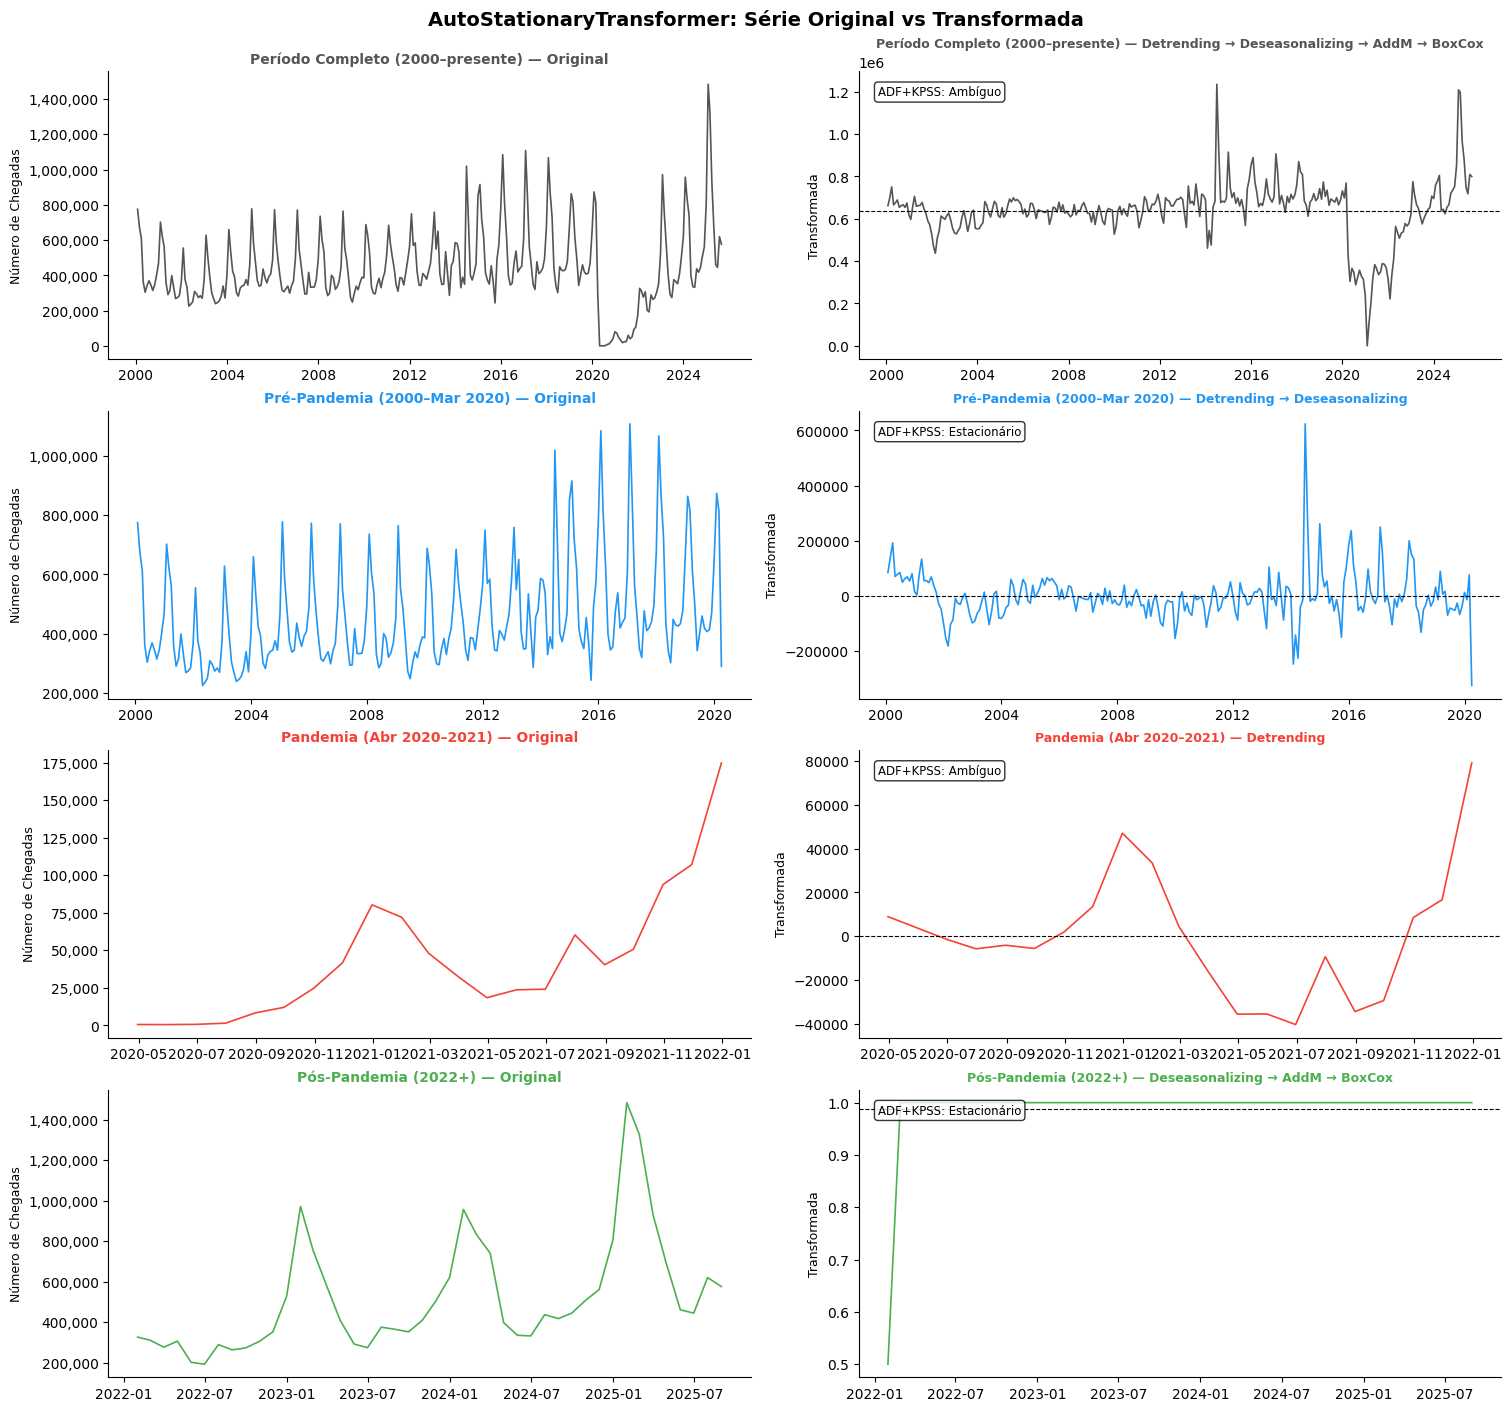

In [181]:
fig, axes = plt.subplots(4, 2, figsize=(15, 14), constrained_layout=True)
fig.suptitle(
    'AutoStationaryTransformer: Série Original vs Transformada',
    fontsize=14,
    fontweight='bold',
)

for row, (label, series) in enumerate(period_series.items()):
    color = period_series_colors[label]
    transformed = auto_outputs[label]
    pipeline = auto_summary.loc[label, 'Pipeline']

    axes[row, 0].plot(series.index, series, color=color, linewidth=1.2)
    axes[row, 0].set_title(
        f'{label} — Original', fontsize=10, fontweight='bold', color=color
    )
    axes[row, 0].set_ylabel('Número de Chegadas', fontsize=9)
    axes[row, 0].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{int(x):,}')
    )

    axes[row, 1].plot(transformed.index, transformed, color=color, linewidth=1.2)
    axes[row, 1].axhline(
        transformed.mean(), color='black', linewidth=0.8, linestyle='--'
    )
    axes[row, 1].set_title(
        f'{label} — {pipeline}', fontsize=9, fontweight='bold', color=color
    )
    axes[row, 1].set_ylabel('Transformada', fontsize=9)
    axes[row, 1].annotate(
        f'ADF+KPSS: {auto_summary.loc[label, "Veredito conjunto"] if "Veredito conjunto" in auto_summary.columns else auto_summary.loc[label, "Joint verdict"]}',
        xy=(0.03, 0.95),
        xycoords='axes fraction',
        va='top',
        fontsize=8.5,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8),
    )

    for ax in axes[row]:
        sns.despine(ax=ax)

plt.show()